# Import Modules

In [1]:
import importlib
import os
import sys

import joblib
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split

In [2]:
os.chdir("../")
sys.path.insert(0, os.getcwd())

In [3]:
from morai.experience import charters, experience
from morai.forecast import metrics, preprocessors
from morai.models import core
from morai.utils import custom_logger, helpers

In [4]:
logger = custom_logger.setup_logging(__name__)

In [5]:
# update log level if wanting more logging
custom_logger.set_log_level("INFO")

In [6]:
pd.options.display.float_format = "{:,.2f}".format

In [7]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

In [8]:
pl_parquet_path = helpers.FILES_PATH / "dataset" / "raw_mortality_grouped_1223.parquet"

In [9]:
# reading in the dataset
pl.enable_string_cache()
lzdf = pl.scan_parquet(
    pl_parquet_path,
)

In [10]:
initial_row_count = lzdf.select(pl.len()).collect().item()
print(
    f"row count: {initial_row_count:,} \n"
    f"exposures: {lzdf.select([pl.col('amount_exposed').sum()]).collect()[0,0]:,}"
)

row count: 52,057,334 
exposures: 170,731,836,069,650.22


In [11]:
grouped_df = lzdf.collect()

In [12]:
grouped_df = grouped_df.to_pandas()

In [13]:
grouped_df = helpers.clean_df(grouped_df)

 2026-07-12 21:35:12 | morai.utils.helpers | INFO     | lowercasing the column names 
 2026-07-12 21:35:12 | morai.utils.helpers | INFO     | replacing special characters with underscores in the column names 
 2026-07-12 21:35:12 | morai.utils.helpers | INFO     | removed unused categories and reorder 
 2026-07-12 21:36:45 | morai.utils.helpers | INFO     | update index to int32 
 2026-07-12 21:36:46 | morai.utils.helpers | INFO     | dataFrame shape: (52057334, 29) 


In [14]:
grouped_df.dtypes

observation_year            int64
sex                      category
smoker_status            category
insurance_plan           category
issue_age                   int32
duration                    int32
face_amount_band         category
issue_year                  int32
attained_age                int32
soa_post_lvl_ind         category
number_of_pfd_classes    category
preferred_class          category
soa_antp_lvl_tp          category
soa_guar_lvl_tp          category
mib_flag                 category
preferred_indicator      category
slct_ult_ind             category
amount_exposed            float64
policies_exposed          float64
death_claim_amount          int64
death_count                 int64
cen2momp1wmi_byamt        float64
cen2momp2wmi_byamt        float64
class_enh                category
qx_vbt15                  float64
qx_raw                    float64
qx_log_raw                float64
exp_amt_vbt15             float64
ae_vbt15                  float64
dtype: object

# Preparing Data

## Filter

In [15]:
model_data = grouped_df[
    (grouped_df["issue_age"] >= 18)
    & (grouped_df["issue_age"] <= 95)
    & (grouped_df["observation_year"] >= 2012)
    & ~(grouped_df["soa_post_lvl_ind"].isin(["PLT"]))
    & (grouped_df["insurance_plan"]!="Other")
    & (grouped_df["smoker_status"]!="U")
].copy()
model_data = model_data.reset_index(drop=True)

In [16]:
model_data = model_data[
    (model_data["attained_age"] >= 50)
    & (model_data["attained_age"] <= 95)
    & (model_data["issue_age"] >= 30)
    & (model_data["issue_age"] <= 80)
].copy()

In [17]:
model_data = model_data[(model_data["observation_year"] <= 2019)].copy()
# model_data = model_data[~model_data["observation_year"].isin([2020, 2021, 2022])].copy()

In [18]:
del grouped_df

## Calculated Fields

In [19]:
model_data["capped_duration"] = model_data["duration"].clip(upper=26)
model_data["qx_log_raw"] = np.log(model_data["qx_raw"] + 1)
binned_face_dict = {
    "01: 0 - 9,999": "01: 0 - 24,999",
    "02: 10,000 - 24,999": "01: 0 - 24,999",
    "03: 25,000 - 49,999": "02: 25,000 - 99,999",
    "04: 50,000 - 99,999": "02: 25,000 - 99,999",
    "05: 100,000 - 249,999": "03: 100,000 - 249,999",
    "06: 250,000 - 499,999": "04: 250,000 - 4,999,999",
    "07: 500,000 - 999,999": "04: 250,000 - 4,999,999",
    "08: 1,000,000 - 2,499,999": "04: 250,000 - 4,999,999",
    "09: 2,500,000 - 4,999,999": "04: 250,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999": "05: 5,000,000+",
    "11: 10,000,000+": "05: 5,000,000+",
}
model_data["binned_face"] = model_data["face_amount_band"].map(binned_face_dict)
model_data["binned_face"] = model_data["binned_face"].astype("category")

## Feature Dictionary

In [20]:
feature_dict = {
    "target": ["qx_raw"],
    "weight": ["amount_exposed"],
    "passthrough": ["attained_age", "duration", "observation_year"],
    "ordinal": [
        "sex",
        "smoker_status",
    ],
    "ohe": [
        "binned_face",
        "insurance_plan",
        "class_enh",
    ],
    "nominal": [],
}

## Model Results Dictionary

In [21]:
metric_cols = ["ae", "smape", "r2_score", "root_mean_squared_error", "aic", "shape"]
model_results = metrics.ModelResults(metrics=metric_cols)

### VBT15

In [22]:
model_name = "vbt15"

In [23]:
scorecard = model_results.get_scorecard(
    y_true_train=model_data["death_claim_amount"],
    y_pred_train=model_data[f"exp_amt_{model_name}"],
    weights_train=None,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=None,
    model_params=None,
    scorecard=scorecard,
    importance=None,
)

 2026-07-12 21:38:59 | morai.forecast.metrics | INFO     | Adding model 'vbt15' 


# Forecasting Models

In [24]:
# build
model_build = True
model_load = False
model_save = True

In [25]:
# load
model_build = False
model_load = True
model_save = False

## GLM

**Overview:**
- GLM is a flexible generalization of ordinary linear regression models. It supports non-normal distributions of the dependent variable.

**Feature Preprocessing:**
  - GLM - using one-hot enconding (ohe) as the model needs the categories to be diferentiated and not ordinal or nominal. This only applies to non-binary features.
  - Scaling should be considered to ensure the features aren't overly weighted by larger values.

**Model Characteristics**
  - GLM is a simpler type of model and is easily understandable. May struggle with complex, non-linear interactions without suitable transformations or feature engineering.

In [154]:
model_name = "glm_1219_amt"

In [155]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=False,
    add_constant=True,
)

 2026-07-06 03:27:56 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-07-06 03:27:56 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-07-06 03:27:56 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-07-06 03:27:56 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['duration', 'attained_age', 'observation_year', 'constant'] 
 2026-07-06 03:27:56 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['sex', 'smoker_status'] 
 2026-07-06 03:28:00 | morai.forecast.preprocessors | INFO     | ohe - one hot encoded (dropping first col): ['class_enh', 'insurance_plan', 'binned_face'] 


In [156]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

In [ ]:
GLM = core.GLM()
if model_build:
    GLM.fit(X=X, y=y, weights=weights, r_style=False, )
if model_load:
    GLM.model = joblib.load(helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"loaded model '{model_name}'. type: {type(GLM.model)}")
    GLM.is_fitted_ = True
if model_save:
    joblib.dump(GLM.model, helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"saved model '{model_name}'. type: {type(GLM.model)}")

model_params = {"weights": True, "r_style": False}
model_params.update({"family": GLM.model.family})

In [38]:
print(GLM.model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 qx_raw   No. Observations:             10910770
Model:                            GLM   Df Residuals:                 10910745
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.4291e+11
Date:                Sun, 05 Jul 2026   Deviance:                   9.2506e+11
Time:                        23:23:43   Pearson chi2:                 5.88e+12
No. Iterations:                    12   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
at

In [39]:
predictions = GLM.predict(X)
print(f"NA values: {np.isnan(predictions).sum()}")

NA values: 0


In [40]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [41]:
odds = GLM.get_odds(display=False)
importance = core.ModelWrapper(GLM.model).get_importance()

 2026-07-05 23:23:48 | morai.models.core | INFO     | generating odds ratio from model 


In [42]:
odds

attained_age                            1.12
binned_face_02: 25,000 - 99,999         0.86
binned_face_03: 100,000 - 249,999       0.78
binned_face_04: 250,000 - 4,999,999     0.75
binned_face_05: 5,000,000+              0.70
class_enh_2_2                           1.41
class_enh_3_1                           0.75
class_enh_3_2                           0.86
class_enh_3_3                           1.20
class_enh_4_1                           0.71
class_enh_4_2                           0.83
class_enh_4_3                           1.02
class_enh_4_4                           1.15
class_enh_NA_NA                         1.08
class_enh_U_U                           1.03
constant                              512.10
duration                                1.03
insurance_plan_Term                     1.25
insurance_plan_UL                       1.29
insurance_plan_ULSG                     1.23
insurance_plan_VL                       1.22
insurance_plan_VLSG                     1.28
observatio

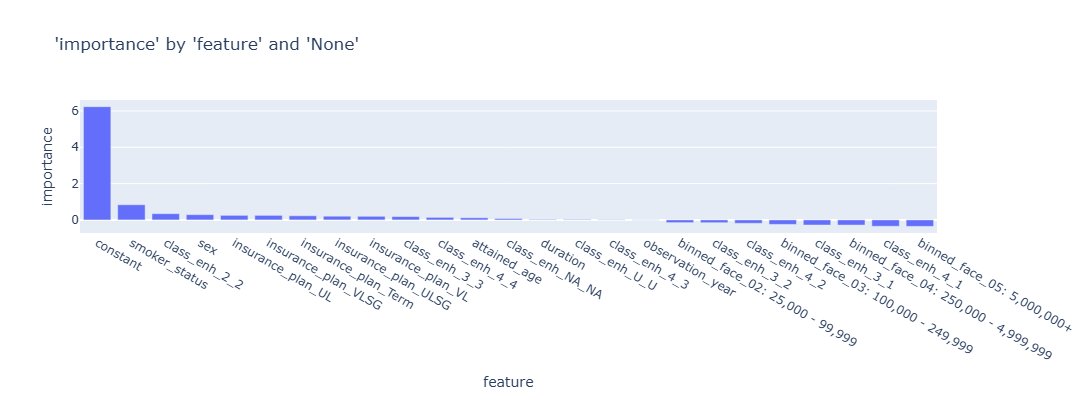

In [43]:
charters.chart(
    df=importance, x_axis="feature", y_axis="importance", type="bar", y_sort=True
)

In [44]:
scorecard = model_results.get_scorecard(
    y_true_train=y_train,
    y_pred_train=GLM.model.predict(X_train),
    weights_train=weights_train,
    y_true_test=y_test,
    y_pred_test=GLM.model.predict(X_test),
    weights_test=weights_test,
    model=GLM.model,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=preprocess_dict,
    model_params=model_params,
    scorecard=scorecard,
    importance=importance,
)

 2026-07-05 23:23:50 | morai.forecast.metrics | INFO     | Adding model 'glm_1219_amt' 


 2026-07-05 23:23:51 | morai.experience.charters | INFO     | Binning feature: [issue_year] with 6 bins 


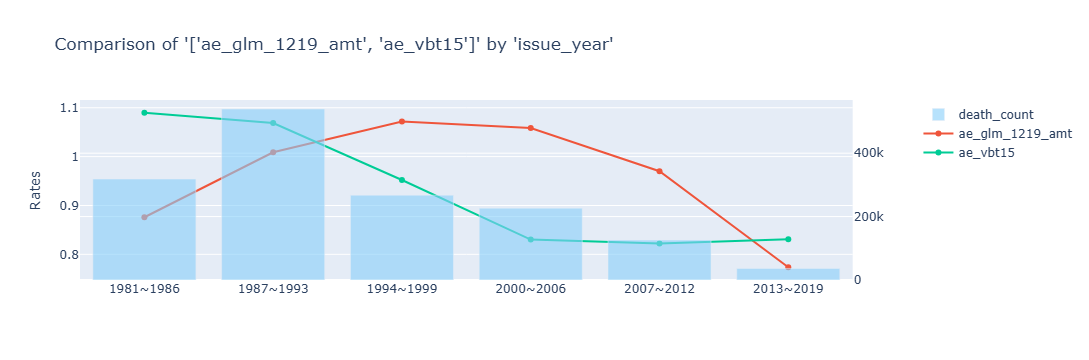

In [45]:
charters.compare_rates(
    df=model_data,
    x_axis="issue_year",
    rates=[f"ae_{model_name}", "ae_vbt15"],
    weights=[f"exp_amt_{model_name}", "exp_amt_vbt15"],
    secondary="death_count",
    x_bins=6,
    display=True,
)

 2026-07-05 23:23:53 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


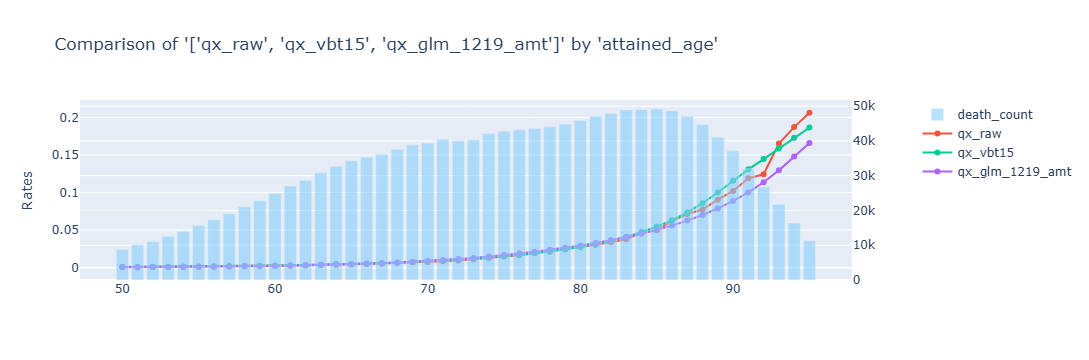

In [46]:
charters.compare_rates(
    model_data,
    x_axis="attained_age",
    rates=["qx_raw", "qx_vbt15", f"qx_{model_name}"],
    weights=["amount_exposed"],
    secondary="death_count",
    y_log=False,
)

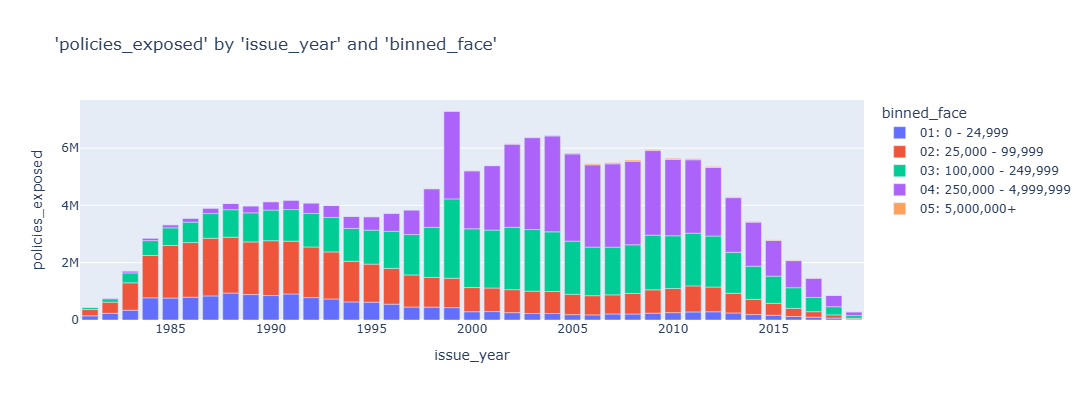

In [47]:
charters.chart(
    df=model_data,
    x_axis="issue_year",
    y_axis="policies_exposed",
    color="binned_face",
    type="bar",
)

 2026-07-05 23:23:58 | morai.experience.charters | INFO     | Creating '10' target plots. 


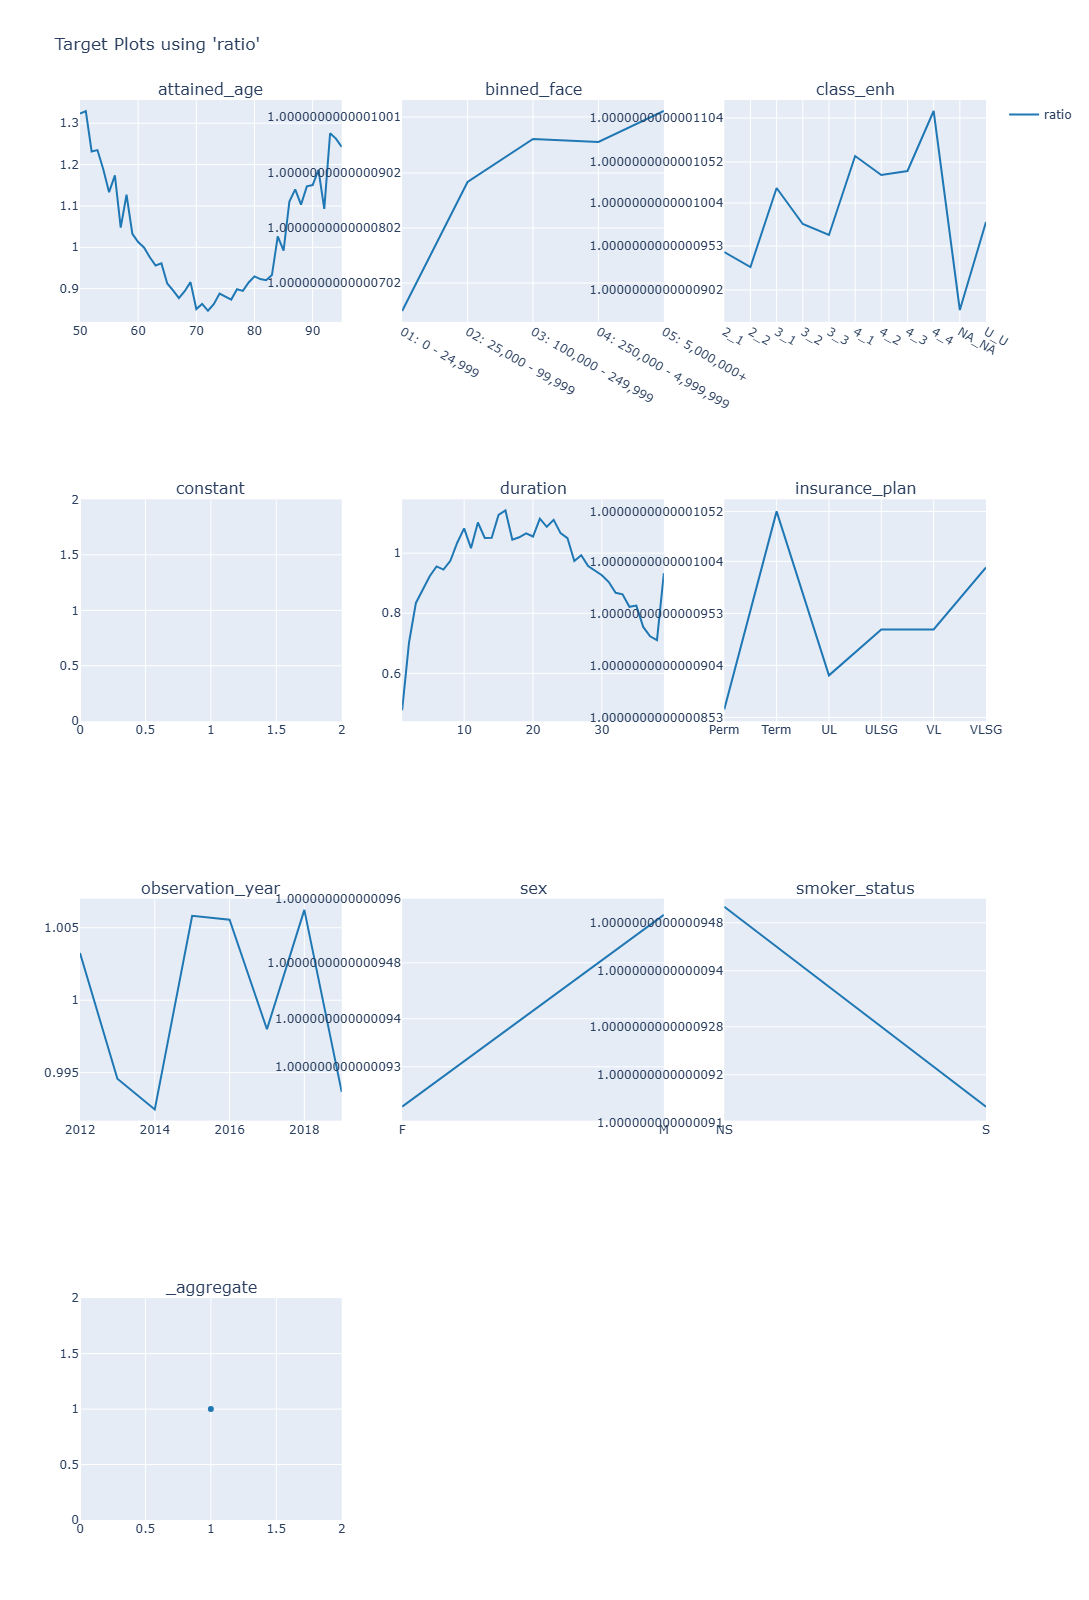

In [48]:
charters.target(
    df=model_data,
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=[f"exp_amt_{model_name}"],
).show()

In [49]:
fig = charters.pdp(
    model=GLM.model,
    df=md_encoded[
        (
            (md_encoded["attained_age"] >= 50)
            & (md_encoded["attained_age"] <= 95)
            & (
                (md_encoded["observation_year"] == 2012)
                | (md_encoded["observation_year"] == 2019)
            )
        )
    ],
    x_axis="observation_year",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=False,
    n_jobs=-1,
)
pd.options.display.float_format = "{:,.5f}".format
pivot = fig.pivot(index='Overall', columns='observation_year', values='%_diff')
pivot['annual_pct_diff'] = (pivot[2012] / pivot[2019]) ** (1/7) - 1
pivot

 2026-07-05 23:24:01 | morai.experience.charters | INFO     | Model: [GLMResultsWrapper] for partial dependence plot. 
 2026-07-05 23:24:01 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-05 23:24:01 | morai.experience.charters | INFO     | x_axis: [observation_year] type: [passthrough] center: [global] 
 2026-07-05 23:24:01 | morai.experience.charters | INFO     | Creating 2 predictions. 
 2026-07-05 23:24:01 | morai.experience.charters | INFO     | Running '11' cores for parallel processing. 


Processing:   0%|          | 0/2 [00:00<?, ?combo/s]

 2026-07-05 23:24:07 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


observation_year,2012,2019,annual_pct_diff
Overall,,,
Overall,1.03315,0.96685,0.00952


## GAM

**Overview:**
- Generalized Additive Models (GAMs) are a class of regression models that combine the interpretability of linear models with the flexibility of non-linear models by fitting separate smooth functions to each feature.
  
**Feature Preprocessing:**
  - GAMs can handle both numeric and categorical features, but numeric features may require scaling or transformation for optimal results.

**Model Characteristics**
  - GAMs handle non-linear relationships effectively through smooth functions while maintaining interpretability.
  - Unlike tree-based models, GAMs do not split data but instead apply smooth functions to individual predictors.

In [38]:
model_name = "gam_1219_amt"

In [39]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=False,
    add_constant=True,
)

 2026-05-27 02:33:22 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-05-27 02:33:23 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-05-27 02:33:24 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-05-27 02:33:32 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['observation_year', 'attained_age', 'duration', 'constant'] 
 2026-05-27 02:33:32 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['smoker_status', 'sex'] 
 2026-05-27 02:33:40 | morai.forecast.preprocessors | INFO     | ohe - one hot encoded (dropping first col): ['binned_face', 'insurance_plan', 'class_enh'] 


In [40]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

In [41]:
GAM = r.GAMR()
spline_dict = {
    "attained_age": {"df": 12, "degree": 3, "bs": "ps"},
}
if model_build:
    GAM.setup_model(
        X=X_train, y=y_train, weights=weights_train, spline_dict=spline_dict
    )
if model_load:
    GAM.model = joblib.load(helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"loaded model '{model_name}'. type: {type(GAM.model)}")
    GAM.is_fitted_ = True
if model_save:
    joblib.dump(GAM.model, helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"saved model '{model_name}'. type: {type(GAM.model)}")

model_params = {"weights": True}
model_params.update({"family": GAM.family})
model_params.update({"splne_dict": spline_dict})

 2026-05-27 02:33:49 | morai.models.r | INFO     | setup GAM model with mgcv and `quasibinomial` distribution with `logit` link 
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]: In addition:  
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]: Warning messages:
 
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]: 1:  
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  : 
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]: 
  
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
 
 2026-05-27 02:33:51 | rpy2.rinterface_lib.callbacks | WARNING  | R[write to console]: 2:  
 2026-05-27 02:33:51 | rpy2.rinterface_

In [42]:
predictions = GAM.predict(X)

In [43]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [44]:
scorecard = model_results.get_scorecard(
    y_true_train=y_train,
    y_pred_train=GAM.predict(X_train),
    weights_train=weights_train,
    y_true_test=y_test,
    y_pred_test=GAM.predict(X_test),
    weights_test=weights_test,
    model=GAM.model,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=preprocess_dict,
    model_params=model_params,
    scorecard=scorecard,
    importance=None,
)

 2026-05-27 03:19:54 | morai.forecast.metrics | ERROR    | Model `
Family: quasibinomial 
Link function: logit 

Formula:
qx_raw ~ s(attained_age, k = 12, m = 3, bs = "ps") + binned_face_02__25_000___99_999 + 
    binned_face_03__100_000___249_999 + binned_face_04__250_000___4_999_999 + 
    binned_face_05__5_000_000plus + class_enh_2_2 + class_enh_3_1 + 
    class_enh_3_2 + class_enh_3_3 + class_enh_4_1 + class_enh_4_2 + 
    class_enh_4_3 + class_enh_4_4 + class_enh_NA_NA + class_enh_U_U + 
    constant + duration + insurance_plan_Term + insurance_plan_UL + 
    insurance_plan_ULSG + insurance_plan_VL + insurance_plan_VLSG + 
    observation_year + sex + smoker_status

Estimated degrees of freedom:
8.36  total = 32.36 

fREML score: 60412642     
` does not have AIC attribute, returning None 
 2026-05-27 03:19:54 | morai.forecast.metrics | ERROR    | Model `
Family: quasibinomial 
Link function: logit 

Formula:
qx_raw ~ s(attained_age, k = 12, m = 3, bs = "ps") + binned_face_02__25_

 2026-05-27 03:20:13 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


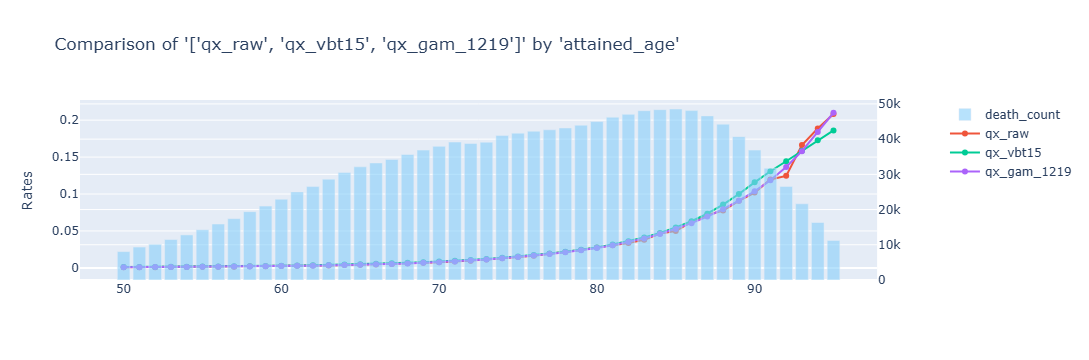

In [45]:
charters.compare_rates(
    model_data,
    x_axis="attained_age",
    rates=["qx_raw", "qx_vbt15", f"qx_{model_name}"],
    weights=["amount_exposed"],
    secondary="death_count",
)

 2026-05-27 03:20:19 | morai.experience.charters | INFO     | Creating '10' target plots. 


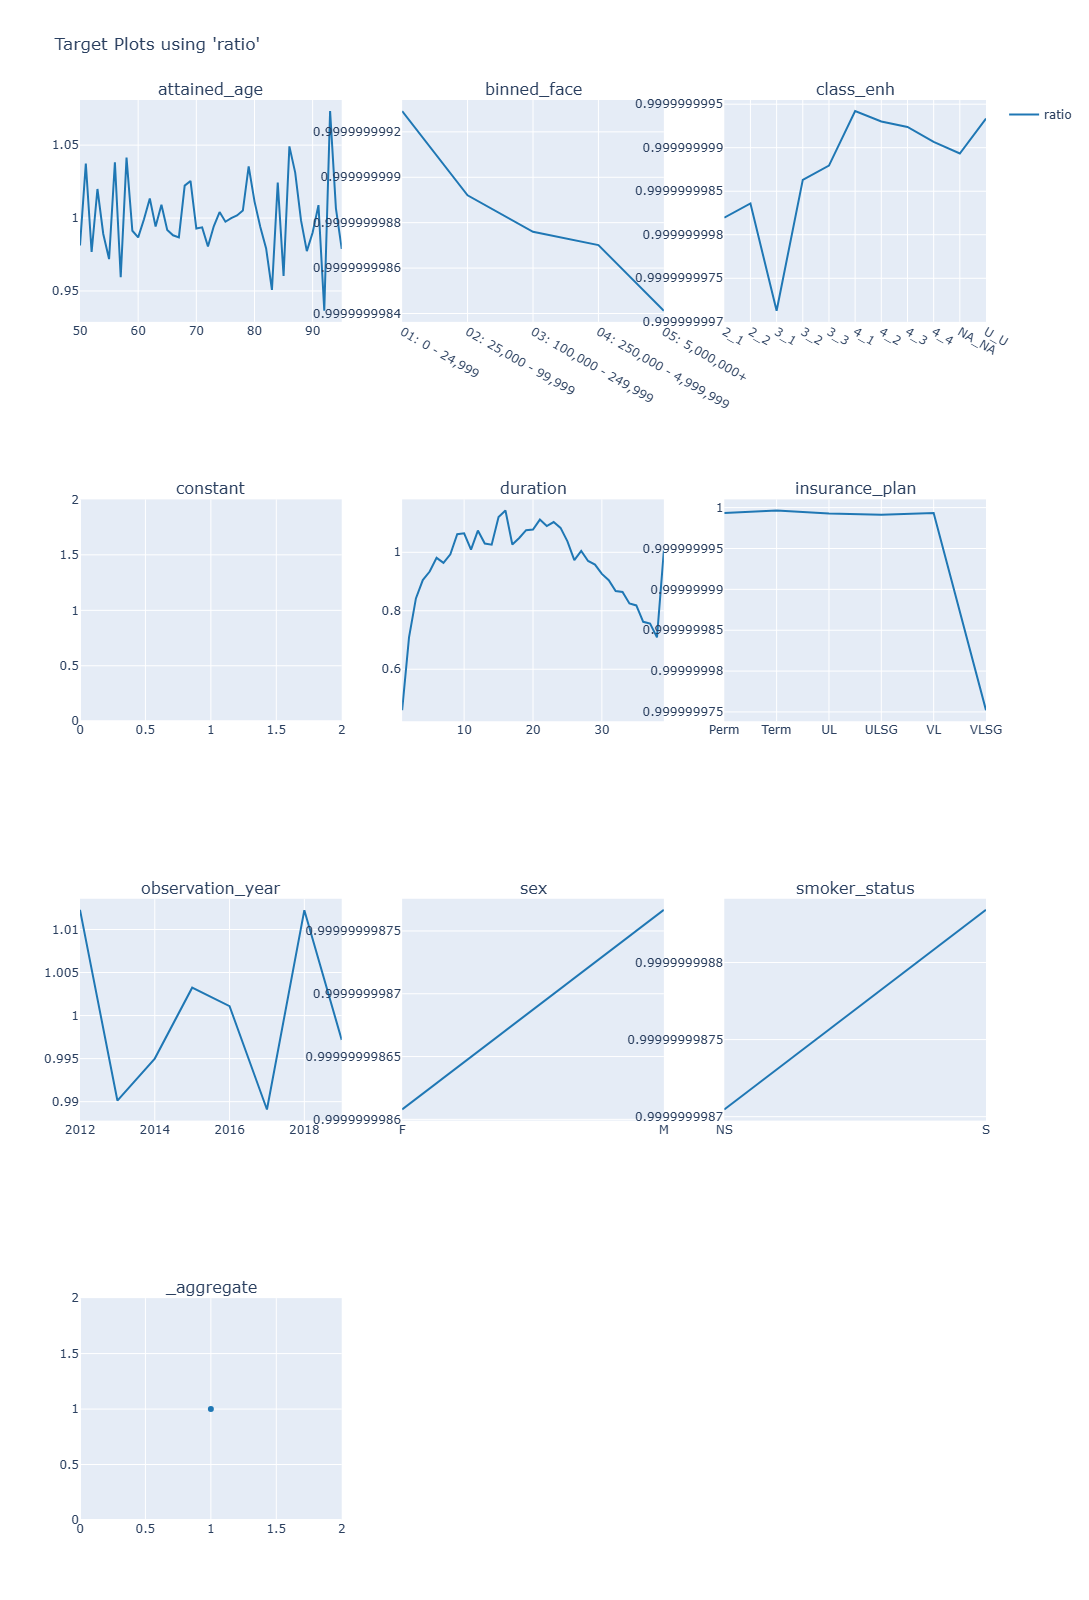

In [46]:
charters.target(
    df=model_data.loc[X_train.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=[f"exp_amt_{model_name}"],
).show()

 2026-05-27 03:20:22 | morai.experience.charters | INFO     | Creating '10' target plots. 


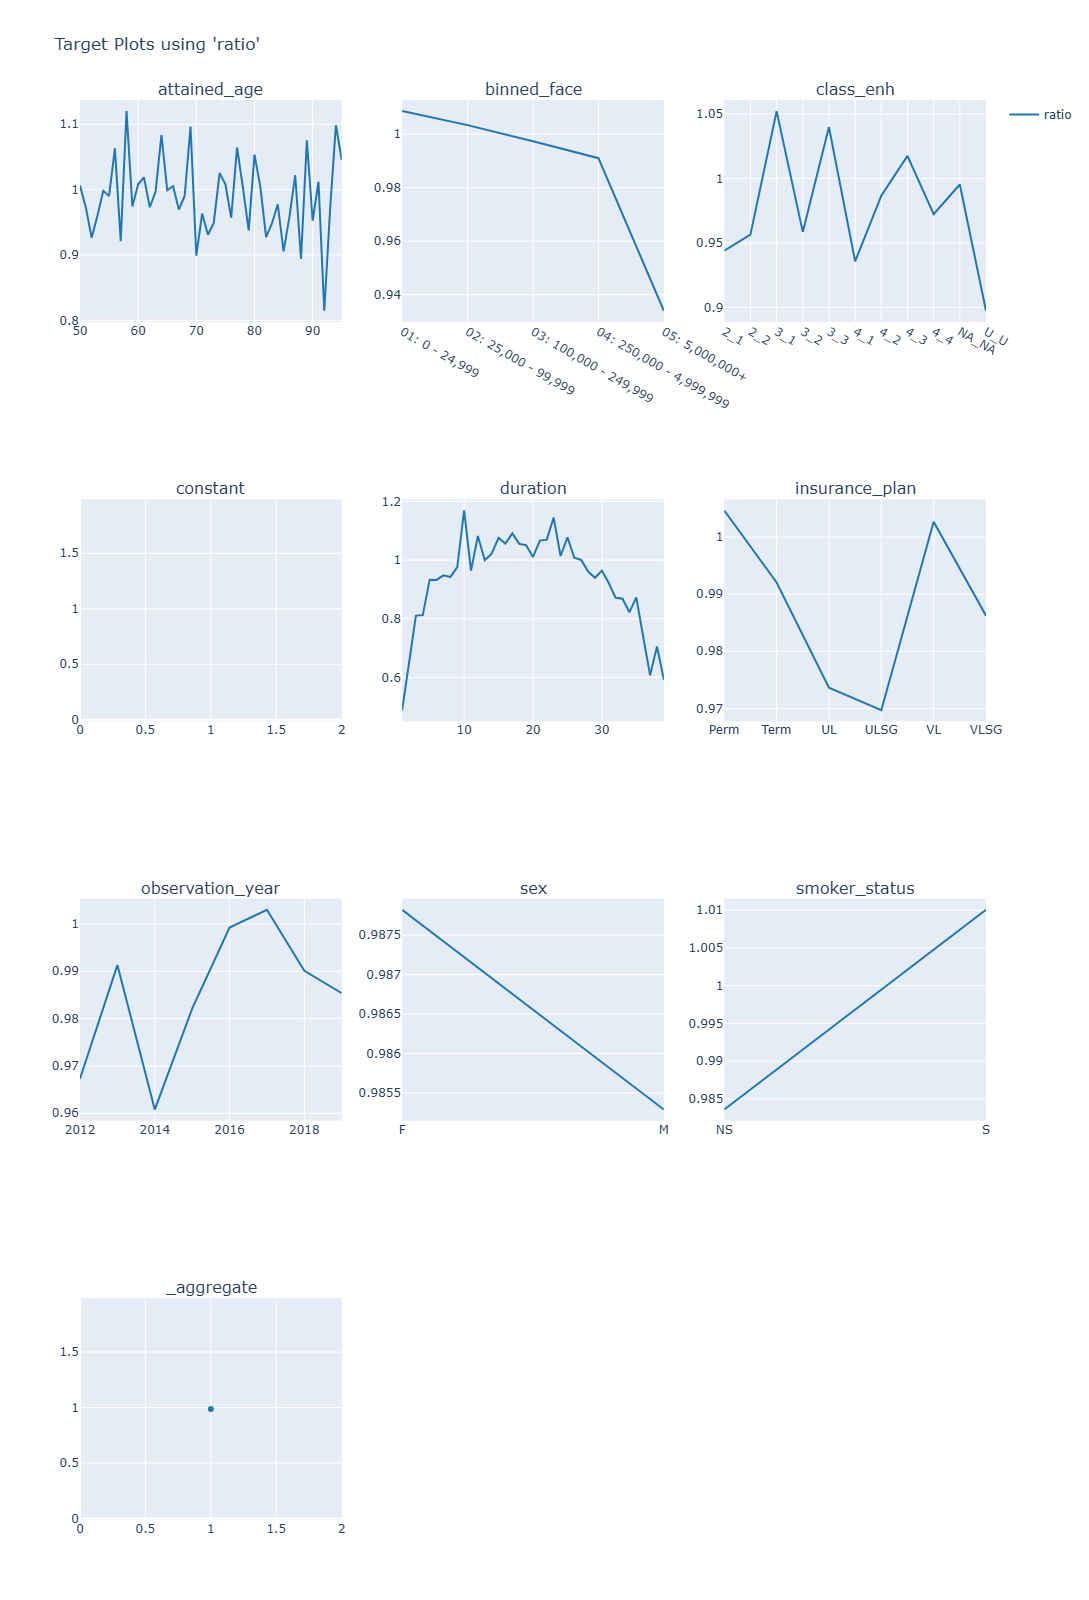

In [47]:
charters.target(
    df=model_data.loc[X_test.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=[f"exp_amt_{model_name}"],
).show()

## Linear Regression

**Feature Preprocessing:**
- Linear regression needs all features to be numeric.

In [50]:
model_name = "lr_1219_amt"

In [51]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=False,
)

 2026-07-05 23:24:07 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-07-05 23:24:07 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-07-05 23:24:08 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['duration', 'attained_age', 'observation_year'] 
 2026-07-05 23:24:08 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['sex', 'smoker_status'] 
 2026-07-05 23:24:11 | morai.forecast.preprocessors | INFO     | ohe - one hot encoded (dropping first col): ['class_enh', 'insurance_plan', 'binned_face'] 


In [52]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

In [53]:
from sklearn import linear_model

if model_build:
    model = linear_model.LinearRegression()
    model.fit(X_train, y_train, sample_weight=weights_train)
if model_load:
    model = joblib.load(helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"loaded model '{model_name}'. type: {type(model)}")
if model_save:
    joblib.dump(model, helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"saved model '{model_name}'. type: {type(model)}")

model_params = {"weights": True}
model_params.update(model.get_params())

 2026-07-05 23:25:32 | __main__ | INFO     | saved model 'lr_1219_amt'. type: <class 'sklearn.linear_model._base.LinearRegression'> 


In [54]:
predictions = model.predict(X)

In [55]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [56]:
importance = core.ModelWrapper(model).get_importance()

In [57]:
scorecard = model_results.get_scorecard(
    y_true_train=y_train,
    y_pred_train=model.predict(X_train),
    weights_train=weights_train,
    y_true_test=y_test,
    y_pred_test=model.predict(X_test),
    weights_test=weights_test,
    model=None,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=preprocess_dict,
    model_params=model_params,
    scorecard=scorecard,
    importance=importance,
)

 2026-07-05 23:26:10 | morai.forecast.metrics | INFO     | Adding model 'lr_1219_amt' 


 2026-07-05 23:26:47 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


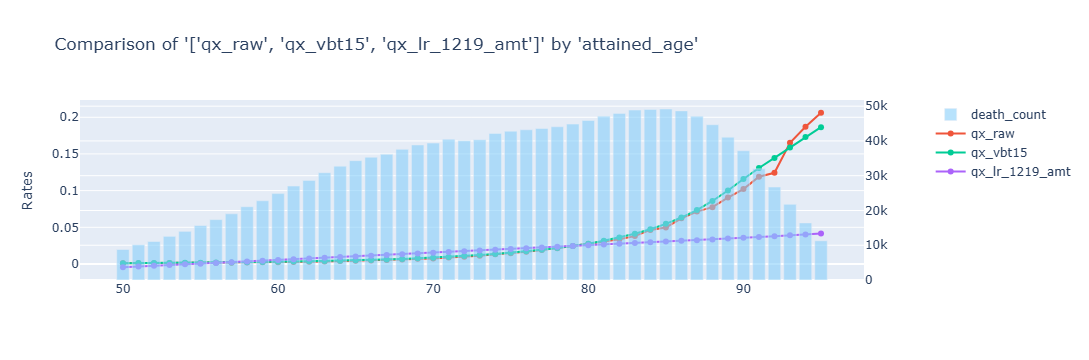

In [58]:
charters.compare_rates(
    model_data,
    x_axis="attained_age",
    rates=["qx_raw", "qx_vbt15", f"qx_{model_name}"],
    weights=["amount_exposed"],
    secondary="death_count",
)

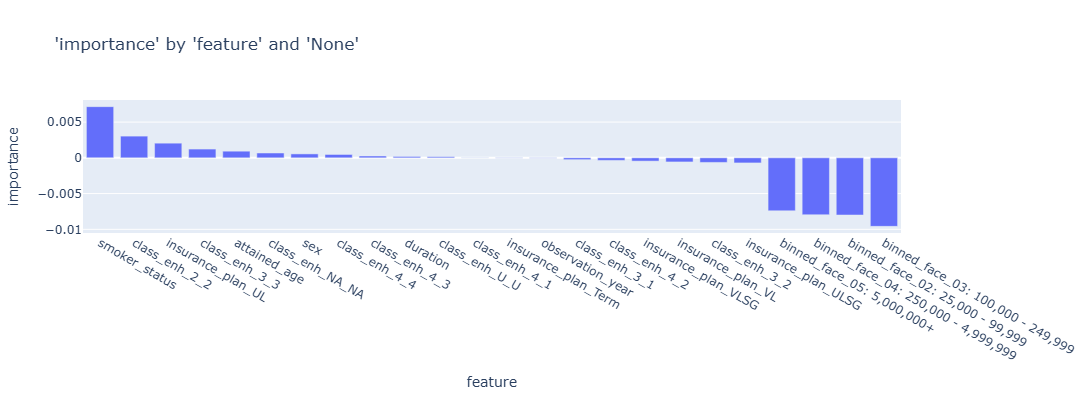

In [59]:
charters.chart(
    df=importance, x_axis="feature", y_axis="importance", type="bar", y_sort=True
)

 2026-07-05 23:27:32 | morai.experience.charters | INFO     | Creating '9' target plots. 


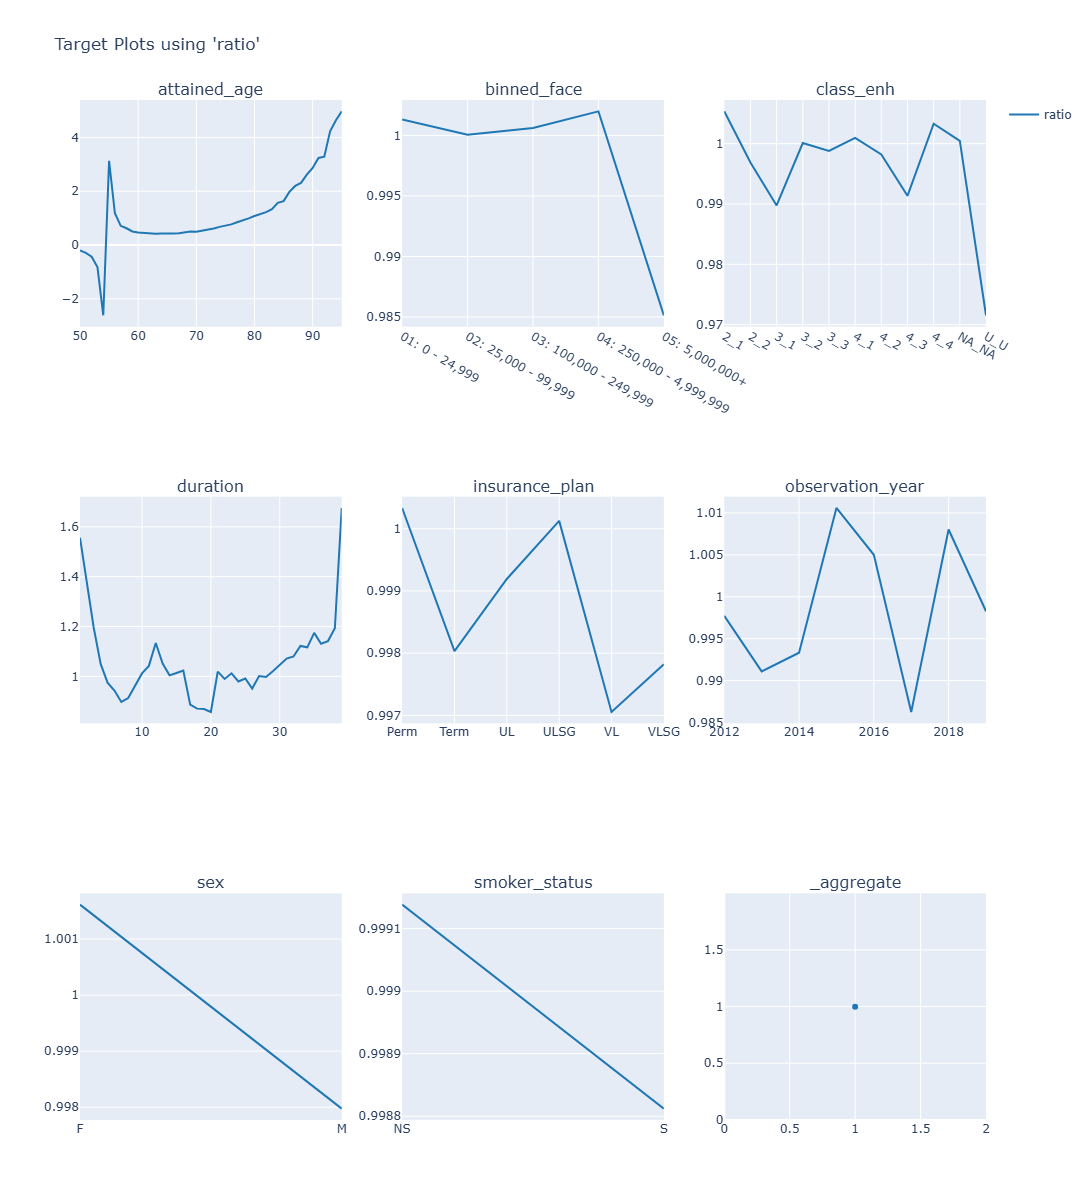

In [60]:
charters.target(
    df=model_data,
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=[f"exp_amt_{model_name}"],
)

## CatBoost

**Overview**
- A CatBoost model is an ensemble of decision trees that are boosted. It is very good with non-linear data, but does not extrapolate well.

**Feature Preprocessing:**
- CatBoost doesn't need all numeric variables and can handle categorical

In [26]:
model_name = "cat_1219_amt"

In [27]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=False,
    preset="pass",
)

 2026-07-12 21:39:00 | morai.forecast.preprocessors | INFO     | using 'pass' preset which makes all features passthrough 
 2026-07-12 21:39:00 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-07-12 21:39:00 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-07-12 21:39:00 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['attained_age', 'observation_year', 'duration', 'smoker_status', 'sex', 'binned_face', 'insurance_plan', 'class_enh'] 


In [28]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

In [29]:
cat_features = feature_dict["ordinal"] + feature_dict["ohe"] + feature_dict["nominal"]
cat_features = list(set(cat_features) & set(model_features))

In [30]:
from catboost import CatBoostRegressor

if model_build:
    model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        cat_features=cat_features,
        one_hot_max_size=11,
        loss_function='Poisson',
        eval_metric='Poisson',
    )
    model.fit(X, y, sample_weight=weights, verbose=0)
if model_load:
    model = joblib.load(helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"loaded model '{model_name}'. type: {type(model)}")
if model_save:
    joblib.dump(model, helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"saved model '{model_name}'. type: {type(model)}")

model_params = {"weights": True}
model_params.update(model.get_params())

 2026-07-12 21:39:12 | __main__ | INFO     | loaded model 'cat_1219_amt'. type: <class 'catboost.core.CatBoostRegressor'> 


In [31]:
predictions = model.predict(X)

In [32]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [68]:
importance = core.ModelWrapper(model).get_importance()

In [69]:
scorecard = model_results.get_scorecard(
    y_true_train=y_train,
    y_pred_train=model.predict(X_train),
    weights_train=weights_train,
    y_true_test=y_test,
    y_pred_test=model.predict(X_test),
    weights_test=weights_test,
    model=None,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=preprocess_dict,
    model_params=model_params,
    scorecard=scorecard,
    importance=importance,
)

 2026-07-05 23:41:36 | morai.forecast.metrics | INFO     | Adding model 'cat_1219_amt' 


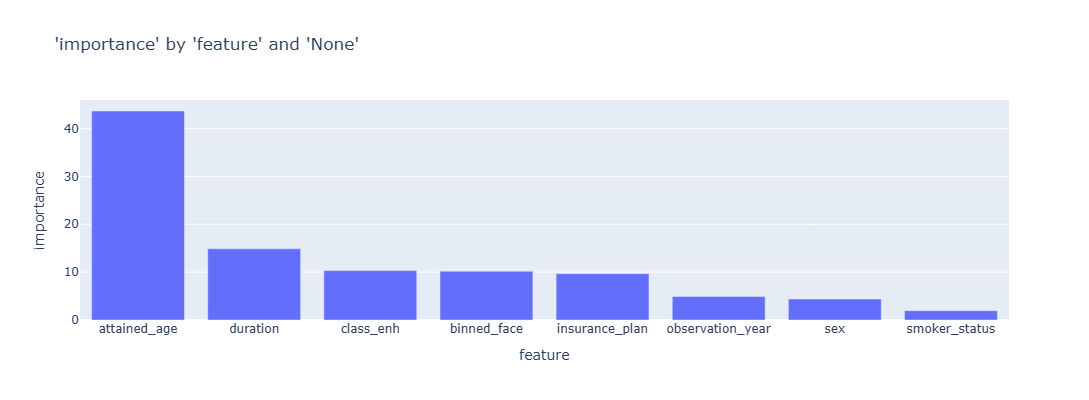

In [70]:
charters.chart(
    df=importance, x_axis="feature", y_axis="importance", type="bar", y_sort=True
)

 2026-07-05 23:42:24 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


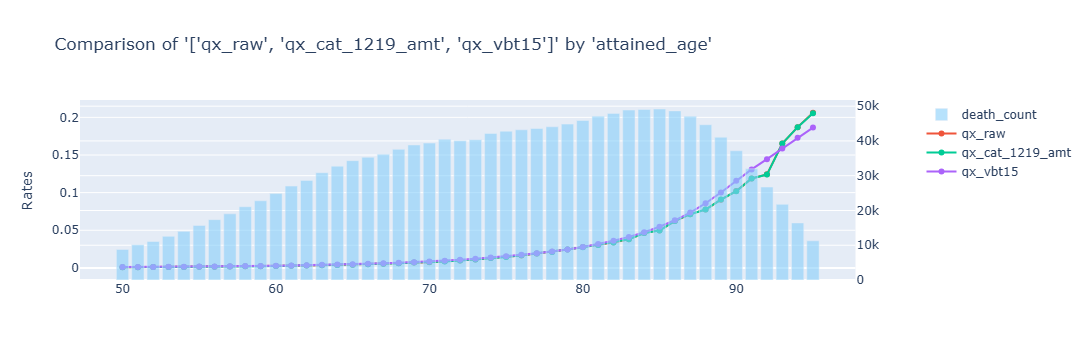

In [71]:
charters.compare_rates(
    model_data,
    x_axis="attained_age",
    rates=["qx_raw", f"qx_{model_name}", "qx_vbt15"],
    weights=["amount_exposed"],
    secondary="death_count",
)

 2026-07-05 23:43:26 | morai.experience.charters | INFO     | Creating '9' target plots. 


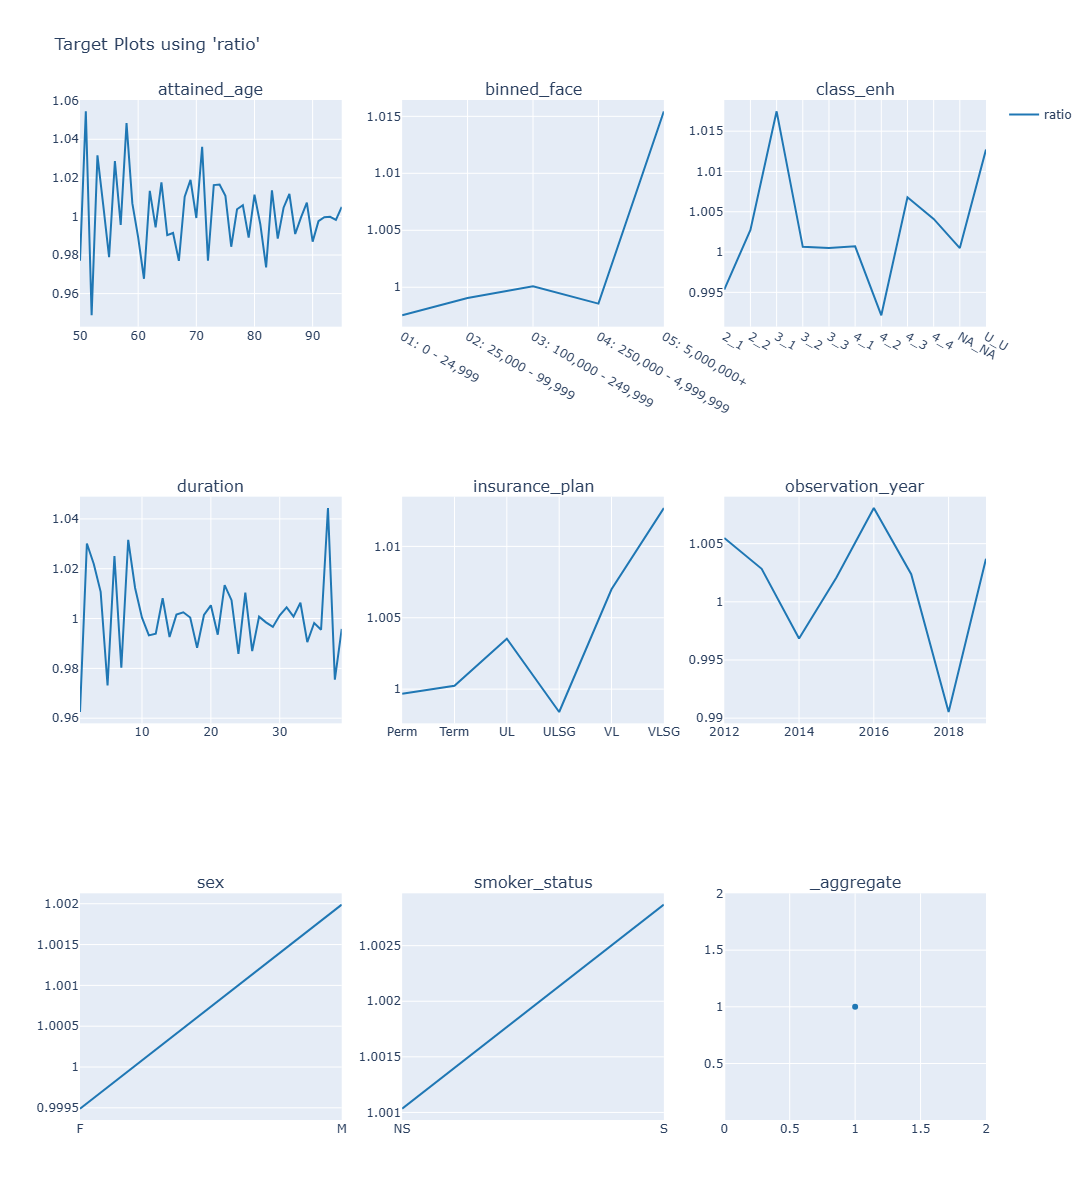

In [72]:
charters.target(
    df=model_data.loc[X_train.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=[f"exp_amt_{model_name}"],
).show()

 2026-07-05 23:43:29 | morai.experience.charters | INFO     | Creating '9' target plots. 


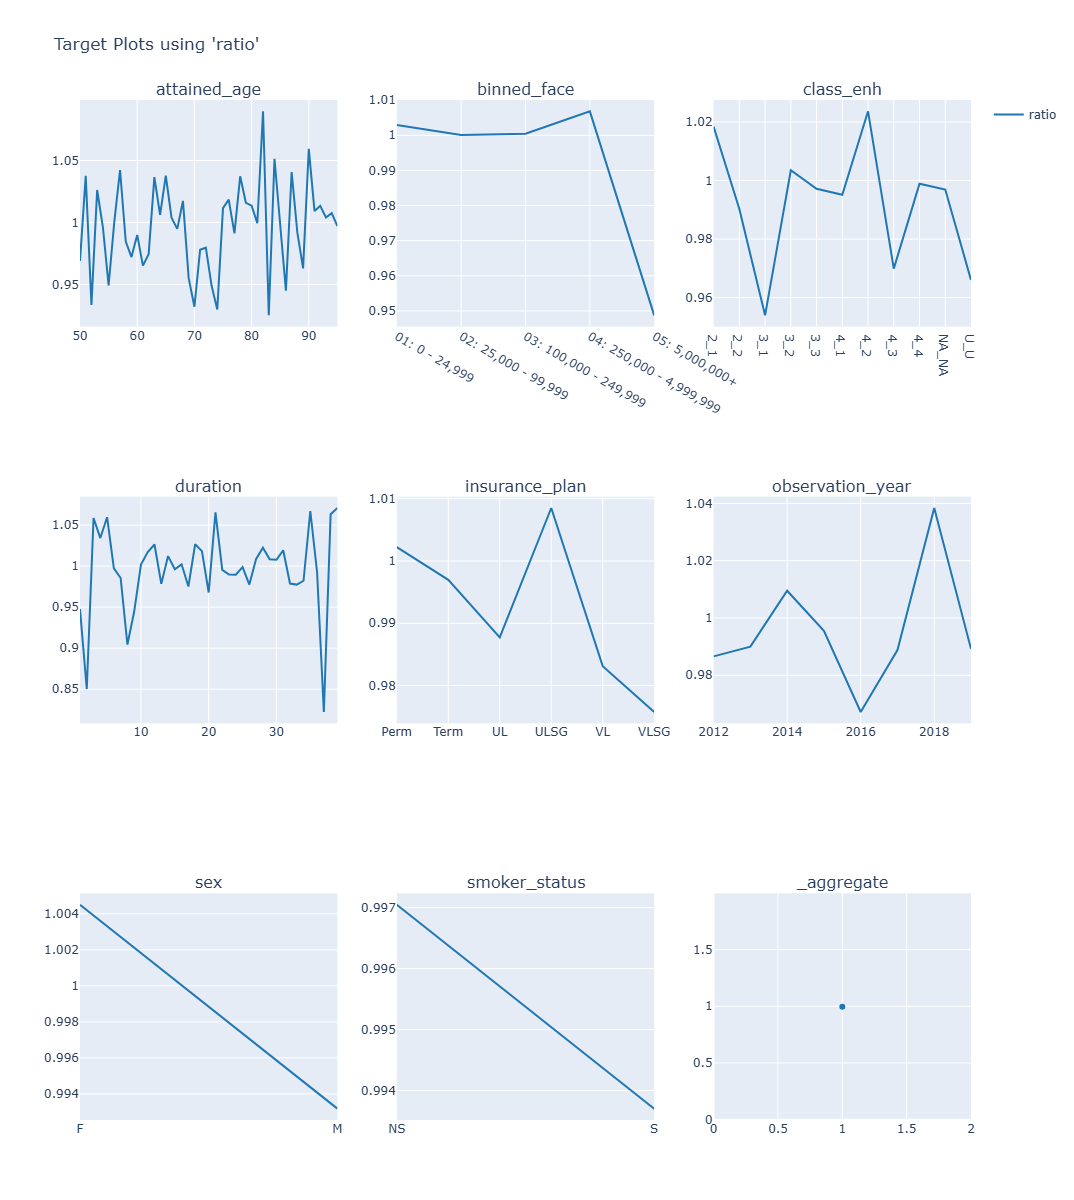

In [73]:
charters.target(
    df=model_data.loc[X_test.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=[f"exp_amt_{model_name}"],
).show()

## Lee Carter

The Lee-Carter model is formulated as follows:

$$\log(m_{x,t}) = a_{x} + b_{x}k_{t} + \epsilon_{x,t}$$

source: https://en.wikipedia.org/wiki/Lee%E2%80%93Carter_model

Where:
- $m_{x,t}$ is the _matrix mortality rate_ at age $x$ in year $t$
- $a_{x}$ describes the general _shape_ of mortality at age $x$ (mean of the time-averaged logs of the central mortality rate at age $x$). This is known as the _age effect_ on mortality.
- $b_{x}$ measures the change in the rates at age $x$ due to a change in the underlying time trend, $k_{t}$.
- $k_{t}$ reflects the effect of the time trend, $t$, on mortality.
- $\epsilon_{x,t}$ are i.i.d. normal random variables with zero means and constant variance, $\sigma^{2}$.

In [74]:
model_name = "lc_1219_amt"

In [75]:
model_params = {"weights": True}
model = core.LeeCarter()

 2026-07-05 23:43:30 | morai.models.core | INFO     | initialized LeeCarter 


In [76]:
lc_df = model.structure_df(model_data)

 2026-07-05 23:43:30 | morai.models.core | INFO     | grouping data by age and year 
 2026-07-05 23:43:30 | morai.models.core | INFO     | calculating qx_raw rates using death_claim_amount and amount_exposed 
 2026-07-05 23:43:30 | morai.models.core | INFO     | floored 0 rates to 0.000001 and capped 0 rates to 0.999999. 
 2026-07-05 23:43:30 | morai.models.core | INFO     | crude_df shape: (368, 5) 


In [77]:
lc_df = model.fit(lc_df)

 2026-07-05 23:43:30 | morai.models.core | INFO     | creating Lee Carter model with qx_raw rates... 
 2026-07-05 23:43:30 | morai.models.core | INFO     | age range: 50, 95 
 2026-07-05 23:43:30 | morai.models.core | INFO     | year range: 2012, 2019 
 2026-07-05 23:43:30 | morai.models.core | INFO     | creating `1` intervals 
 2026-07-05 23:43:30 | morai.models.core | INFO     | adding qx_lc to lc_df 


In [78]:
model_data = model.map(model_data)

 2026-07-05 23:43:30 | morai.models.core | INFO     | mapping qx_lc to df 


In [79]:
lcf_df = model.forecast(years=5)

 2026-07-05 23:44:18 | morai.models.core | INFO     | forecasting qx_lc using deterministic random walk... 


In [80]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [81]:
scorecard = model_results.get_scorecard(
    y_true_train=model_data["death_claim_amount"],
    y_pred_train=model_data[f"exp_amt_{model_name}"],
    weights_train=None,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=None,
    model_params=model_params,
    scorecard=scorecard,
    importance=None,
)

 2026-07-05 23:44:19 | morai.forecast.metrics | INFO     | Adding model 'lc_1219_amt' 


Average log qx shows that mortality rates increase by age

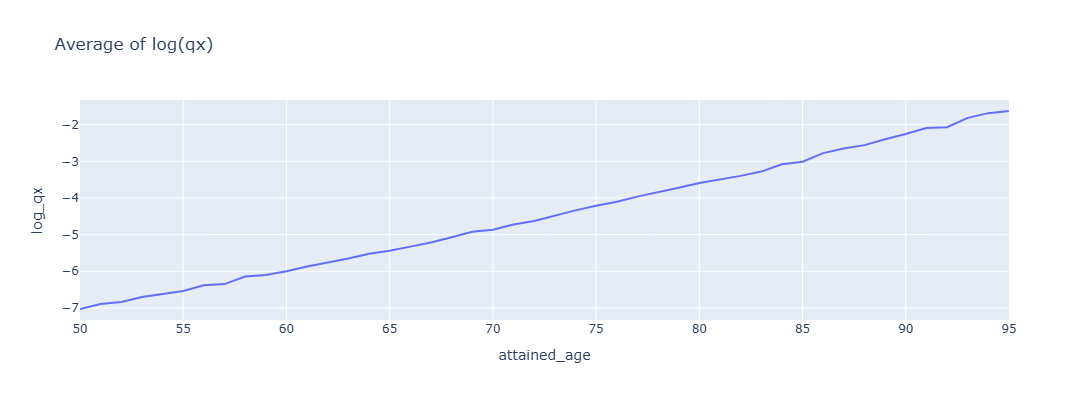

In [82]:
charters.chart(
    df=pd.DataFrame(model.a_x).set_axis([0], axis=1).reset_index(),
    x_axis="attained_age",
    y_axis=0,
    color=None,
    type="line",
    title="Average of log(qx)",
    labels={"attained_age": "attained_age", "0": "log_qx"},
)

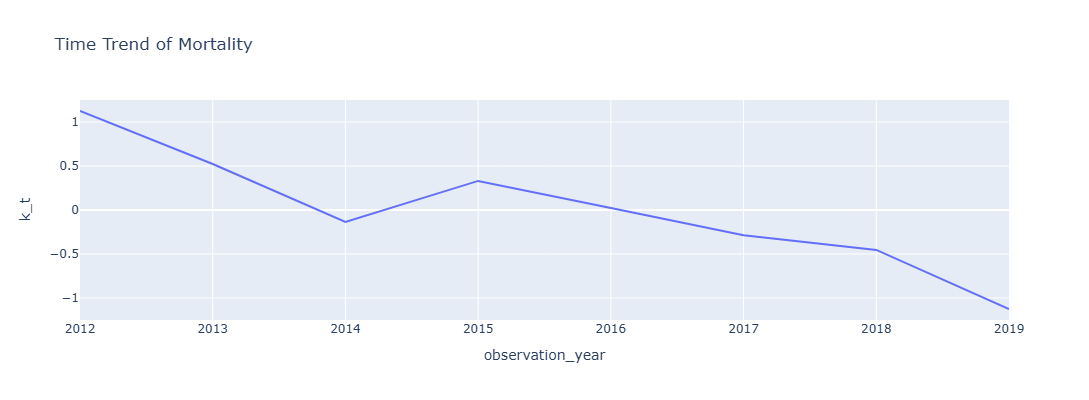

In [83]:
charters.chart(
    df=pd.DataFrame(model.k_t).set_axis([0], axis=1).reset_index(),
    x_axis="observation_year",
    y_axis=0,
    color=None,
    type="line",
    title="Time Trend of Mortality",
    labels={"observation_year": "observation_year", "0": "k_t"},
)

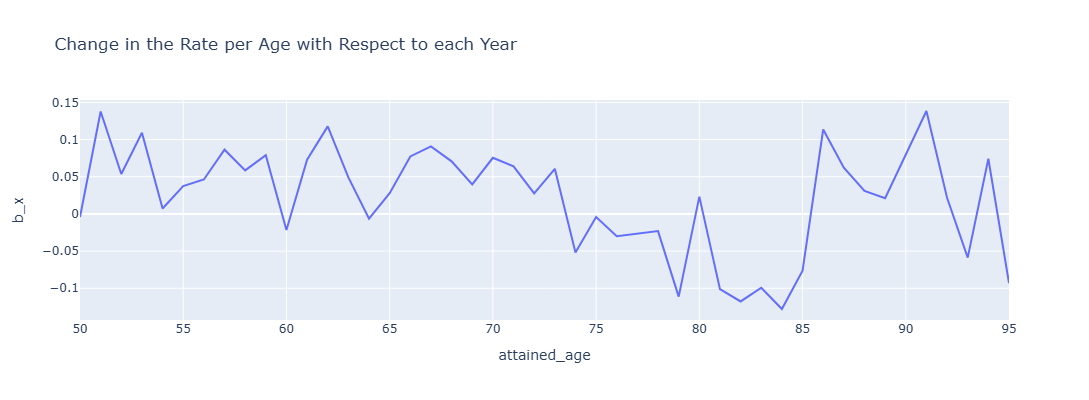

In [84]:
charters.chart(
    df=pd.DataFrame(model.b_x).set_axis([0], axis=1).reset_index(),
    x_axis="attained_age",
    y_axis=0,
    color=None,
    type="line",
    title="Change in the Rate per Age with Respect to each Year",
    labels={"attained_age": "attained_age", "0": "b_x"},
)

 2026-07-05 23:44:57 | morai.experience.charters | INFO     | The weights list is 1 long and should be 2 long. Using the first weight for all weights. 


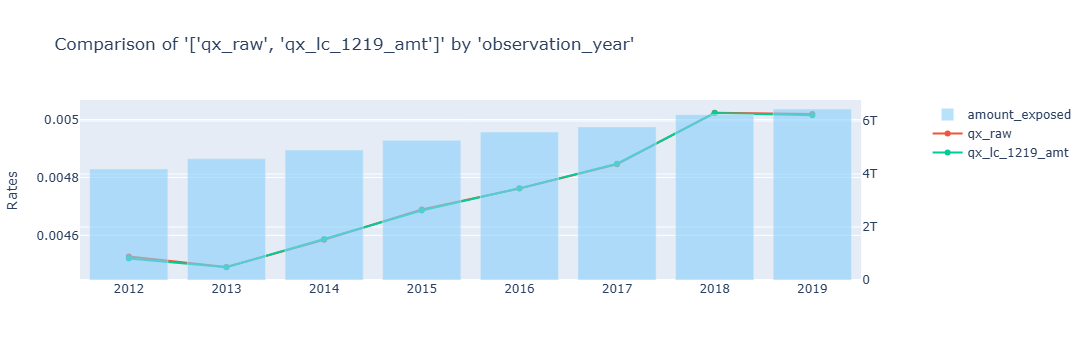

In [85]:
charters.compare_rates(
    model_data,
    x_axis="observation_year",
    rates=["qx_raw", f"qx_{model_name}"],
    weights=["amount_exposed"],
    secondary="amount_exposed",
)

## Cairns-Blake-Dowd Model

The Cairns-Blake-Dowd (CBD) model is a stochastic mortality model, and a variant of the Lee-Carter mortality model. It is designed with longevity risk in mind, particularly attempting to understand and forecast mortality at older ages.

The model is in the following form:

$$\text{logit}(_{t}q_{x}) = \kappa_{t}^{(1)} + (x - \bar{x})\kappa_{t}^{(2)}$$

- $\text{logit}(\alpha) = \log\big(\frac{\alpha}{1-\alpha}\big)$
- $\kappa_{t}^{(1)}$  is the _level_ factor, varying with respect to year $t \in (t_{1}, t_{2}, \dots, t_{q})$
- $\kappa_{t}^{(2)}$  is the _slope_ factor, varying with respect to year $t \in (t_{1}, t_{2}, \dots, t_{q})$
- $x$ is the age group, $x \in (x_{1}, x_{2}, \dots, x_{p})$
- $\bar{x}$ is the average of the age group
- $_{t}q_{x}$ is the probability an individual aged $x$ last birthday dies before age $x+t$

We will be using method of least-squares to get estimates $\hat{\kappa}^{(1)}$ and $\hat{\kappa}^{(2)}$.

Further information:
- https://www.actuaries.org/AFIR/Colloquia/Rome2/Cairns_Blake_Dowd.pdf - further discussion on the merits of the CBD model (such as age-period cohort effects and further extensions to the CBD model).

In [86]:
model_name = "cbd_1219_amt"

In [87]:
model_params = {"weights": True}
model = core.CBD()

 2026-07-05 23:45:08 | morai.models.core | INFO     | initialized CBD 


In [88]:
cbd_df = model.structure_df(model_data)

 2026-07-05 23:45:08 | morai.models.core | INFO     | grouping data by age and year 
 2026-07-05 23:45:08 | morai.models.core | INFO     | calculating qx_raw rates using death_claim_amount and amount_exposed 
 2026-07-05 23:45:08 | morai.models.core | INFO     | floored 0 rates to 0.000001 and capped 0 rates to 0.999999. 
 2026-07-05 23:45:08 | morai.models.core | INFO     | cbd_df shape: (368, 5) 


In [89]:
cbd_df = model.fit(cbd_df)

 2026-07-05 23:45:08 | morai.models.core | INFO     | creating CBD model with qx_raw rates... 
 2026-07-05 23:45:08 | morai.models.core | INFO     | age range: 50, 95 
 2026-07-05 23:45:08 | morai.models.core | INFO     | year range: 2012, 2019 
 2026-07-05 23:45:08 | morai.models.core | INFO     | creating `1` intervals 
 2026-07-05 23:45:08 | morai.models.core | INFO     | adding qx_cbd to cbd_df 


In [90]:
model_data = model.map(model_data)

 2026-07-05 23:45:08 | morai.models.core | INFO     | mapping qx_cbd to df 


In [91]:
cbdf_df = model.forecast(years=5)

 2026-07-05 23:45:35 | morai.models.core | INFO     | forecasting qx_cbd using deterministic random walk... 


In [92]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [93]:
scorecard = model_results.get_scorecard(
    y_true_train=model_data["death_claim_amount"],
    y_pred_train=model_data[f"exp_amt_{model_name}"],
    weights_train=None,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=None,
    model_params=model_params,
    scorecard=scorecard,
    importance=None,
)

 2026-07-05 23:45:35 | morai.forecast.metrics | INFO     | Adding model 'cbd_1219_amt' 


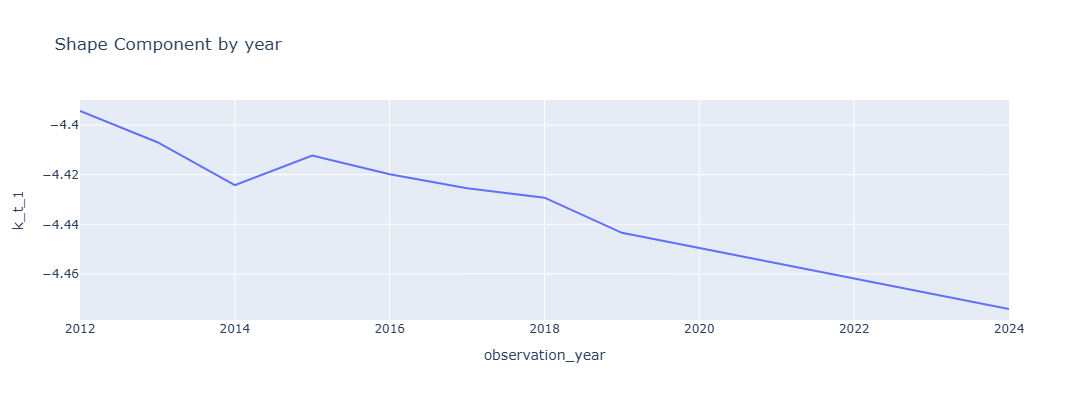

In [94]:
# shape shows the impact of time on mortality
charters.chart(
    df=pd.concat(
        [
            pd.DataFrame(model.k_t_1).set_axis([0], axis=1),
            pd.DataFrame(model.k_1_f).set_axis([0], axis=1),
        ]
    ).reset_index(),
    x_axis=model.year_col,
    y_axis=0,
    color=None,
    type="line",
    title="Shape Component by year",
    labels={"0": "k_t_1"},
)

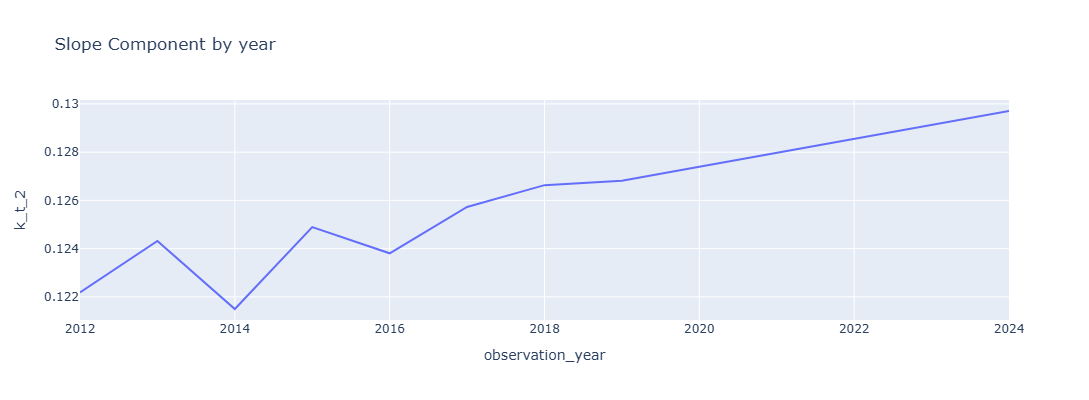

In [95]:
# slope shows if the impact of time is different by year
charters.chart(
    df=pd.concat(
        [
            pd.DataFrame(model.k_t_2).set_axis([0], axis=1),
            pd.DataFrame(model.k_2_f).set_axis([0], axis=1),
        ]
    ).reset_index(),
    x_axis=model.year_col,
    y_axis=0,
    color=None,
    type="line",
    title="Slope Component by year",
    labels={"0": "k_t_2"},
)

 2026-07-05 23:46:17 | morai.experience.charters | INFO     | The weights list is 1 long and should be 2 long. Using the first weight for all weights. 


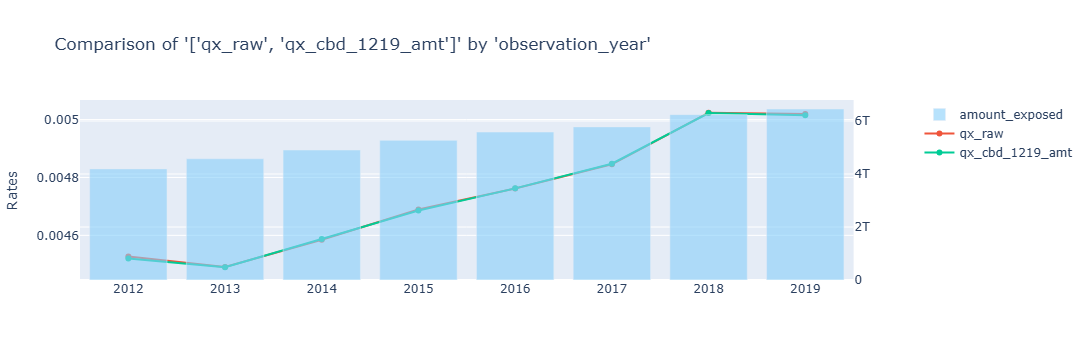

In [96]:
charters.compare_rates(
    model_data,
    x_axis="observation_year",
    rates=["qx_raw", f"qx_{model_name}"],
    weights=["amount_exposed"],
    secondary="amount_exposed",
)

# Model Results

In [97]:
original_float_format = pd.options.display.float_format
pd.options.display.float_format = "{:,.6f}".format  # Increase to 10 decimal places
model_results.scorecard.sort_values(by=("test", "r2_score"), ascending=False)

model_name    train                                                       \
                      ae    smape  r2_score root_mean_squared_error     shape   
3  cat_1219_amt 1.001209 1.924008  0.267494          194,706.007363   8728616   
1  glm_1219_amt 1.000710 1.926070  0.103994          215,342.207819   8728616   
2   lr_1219_amt 1.000000 1.930787 -0.012805          228,947.882860   8728616   
0         vbt15 0.911270 1.926736  0.127797          223,337.251619  17897990   
4   lc_1219_amt 1.000310 1.924013  0.266363          192,695.283253  10910770   
5  cbd_1219_amt 1.000310 1.924013  0.266363          192,695.283253  10910770   

                               test                     \
                       aic       ae    smape  r2_score   
3                      NaN 0.996731 1.924034  0.261278   
1 1,885,817,368,356.485107 0.997170 1.926137  0.108329   
2                      NaN 0.995550 1.930728 -0.019325   
0                      NaN      NaN      NaN       NaN   
4                      NaN      NaN      NaN       NaN   
5                      NaN      NaN      NaN       NaN   

                                                                     
  root_mean_squared_error                      aic            shape  
3          184,433.304278                      NaN 2,182,154.000000  
1          202,628.783052 1,885,817,368,356.485107 2,182,154.000000  
2          216,648.145817                      NaN 2,182,154.000000  
0                     NaN                      NaN              NaN  
4                     NaN                      NaN              NaN  
5                     NaN                      NaN              NaN

In [98]:
pd.options.display.float_format = original_float_format

In [99]:
if model_save:
    model_results.save_model(filepath='model_results.json')
    model_data.to_parquet(helpers.FILES_PATH / "dataset" / "model_data.parquet")
if model_load:
    model_results = metrics.ModelResults(filepath='model_results.json')

 2026-07-05 23:46:23 | morai.forecast.metrics | INFO     | saving results to model_results.json 


In [100]:
rank_df = metrics.ae_rank(
    df=model_data[model_data["insurance_plan"].isin(["UL", "ULSG"])],
    features=model_features,
    actuals="death_claim_amount",
    expecteds="exp_amt_vbt15",
    exposures="amount_exposed",
)
rank_df.head()

 2026-07-05 23:46:40 | morai.forecast.metrics | INFO     | The total AE with exp_amt_vbt15 as E for dataset is 94.8% 


,attribute,attribute_value,death_claim_amount,exp_amt_vbt15,amount_exposed,ae,a-e,exposure_pct,rank_issue,rank_driver,rank_combined
92,class_enh,NA_NA,27635712032,"23,146,627,587.62659","1,806,229,992,805.95190",1.19394,"4,489,084,444.37341",0.22000,1,3,4
42,binned_face,"02: 25,000 - 99,999",11813293034,"9,227,339,772.33498","791,396,001,353.94177",1.28025,"2,585,953,261.66502",0.09639,2,5,7
68,class_enh,2_2,10320633321,"8,955,122,970.22414","485,564,025,624.93665",1.15248,"1,365,510,350.77586",0.05914,3,12,15
63,insurance_plan,UL,48036379355,"46,101,523,722.96735","3,472,252,696,381.63574",1.04197,"1,934,855,632.03265",0.42291,12,14,26
27,binned_face,"03: 100,000 - 249,999",15298734847,"14,107,620,086.78443","1,714,932,819,471.81152",1.08443,"1,191,114,760.21557",0.20888,10,17,27


# Visualizations

## Chart

 2026-07-06 00:28:03 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [amount_exposed] 


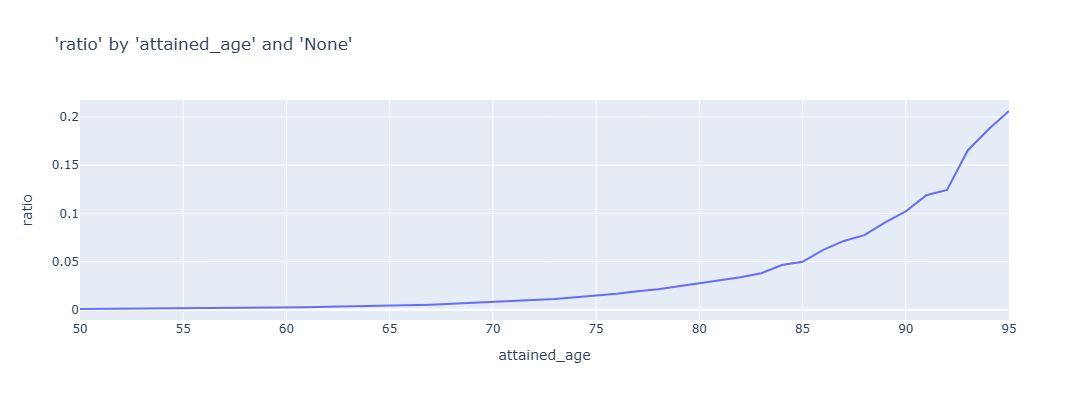

In [101]:
charters.chart(
    df=model_data,
    x_axis="attained_age",
    y_axis="ratio",
    color=None,
    type="line",
    numerator="death_claim_amount",
    denominator="amount_exposed",
)

 2026-07-06 00:31:00 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [amount_exposed] 
 2026-07-06 00:31:00 | morai.experience.charters | INFO     | Binning feature: [duration] with 5 bins 


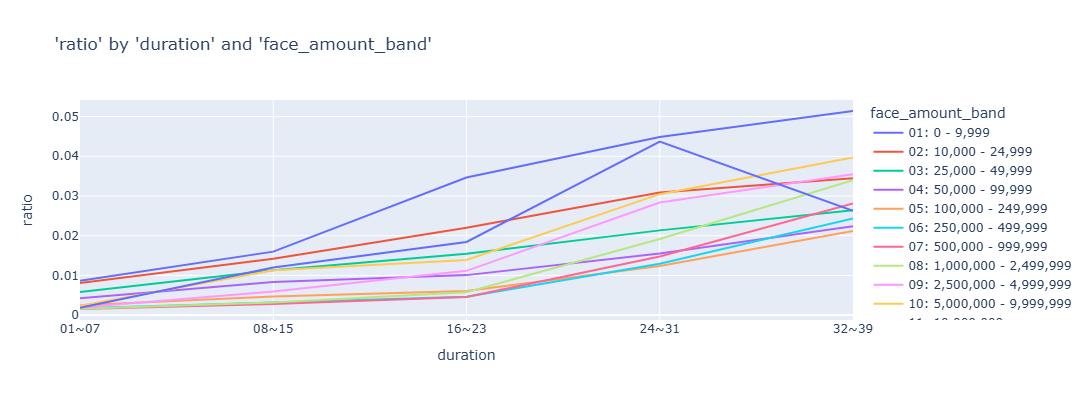

In [102]:
charters.chart(
    df=model_data,
    x_axis="duration",
    y_axis="ratio",
    color="face_amount_band",
    numerator="death_claim_amount",
    denominator="amount_exposed",
    x_bins=5,
    type="line",
)

 2026-07-06 00:32:31 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [amount_exposed] 
 2026-07-06 00:32:31 | morai.experience.charters | INFO     | Binning feature: [duration] with 5 bins 


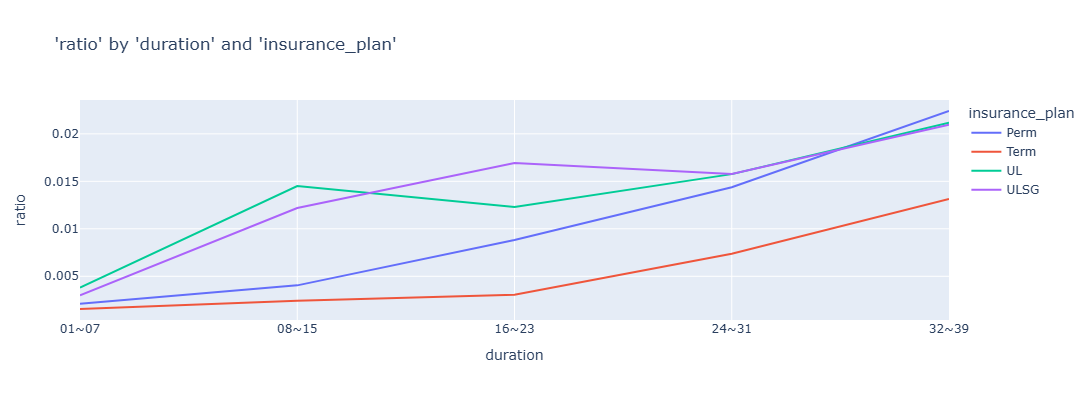

In [103]:
charters.chart(
    df=model_data[
        (model_data["attained_age"] > 50)
        & (model_data["attained_age"] < 90)
        & (model_data["insurance_plan"].isin(["Term", "UL", "Perm", "ULSG"]))
    ],
    x_axis="duration",
    color="insurance_plan",
    y_axis="ratio",
    type="line",
    numerator="death_claim_amount",
    denominator="amount_exposed",
    x_bins=5,
)

This shows that as duration goes up the class structure becomes more NA preferred class structure which has poor a/e

## Compare

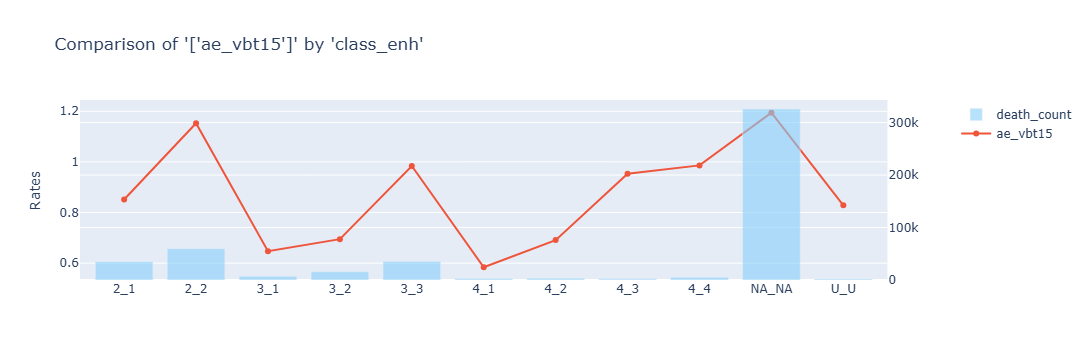

In [104]:
charters.compare_rates(
    df=model_data[model_data["insurance_plan"].isin(["UL", "ULSG"])],
    x_axis="class_enh",
    rates=["ae_vbt15"],
    weights=["exp_amt_vbt15"],
    secondary="death_count",
    display=True,
)

 2026-07-06 00:33:58 | morai.experience.charters | INFO     | Binning feature: [duration] with 5 bins 


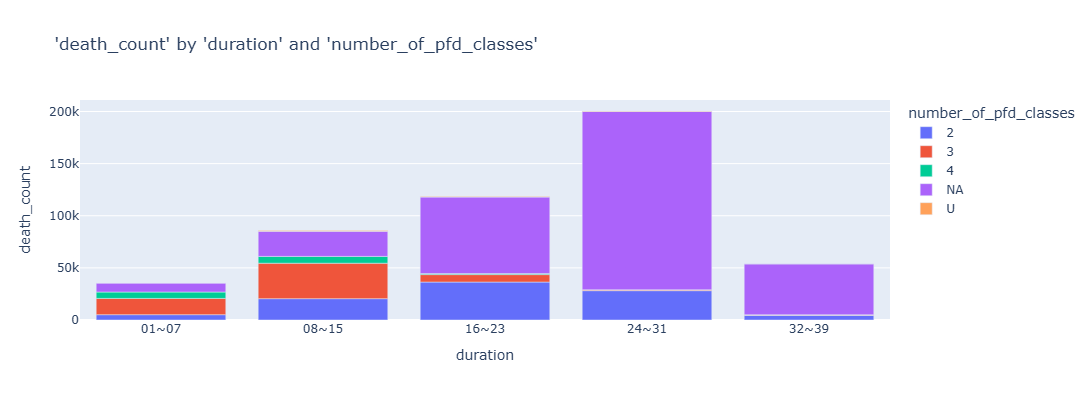

In [105]:
charters.chart(
    df=model_data[model_data["insurance_plan"].isin(["UL", "ULSG"])],
    x_axis="duration",
    y_axis="death_count",
    color="number_of_pfd_classes",
    x_bins=5,
    type="bar",
)

This shows the product sales by year

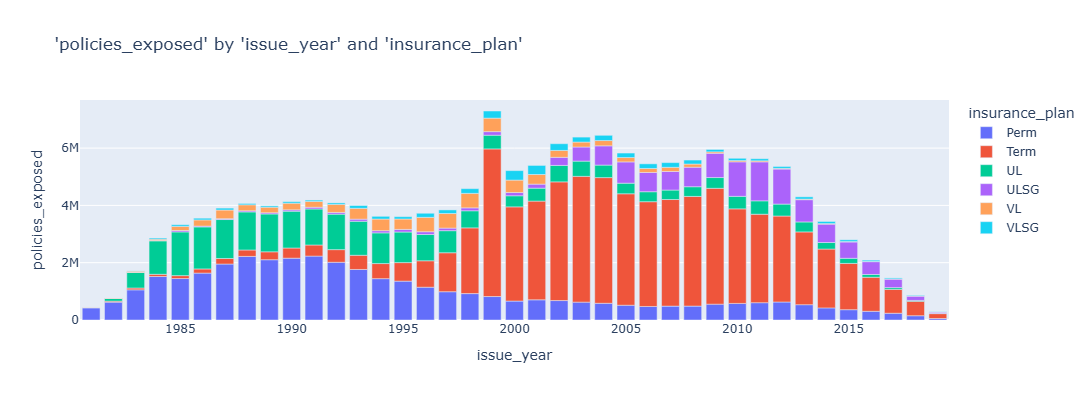

In [106]:
charters.chart(
    df=model_data,
    x_axis="issue_year",
    y_axis="policies_exposed",
    color="insurance_plan",
    type="bar",
)

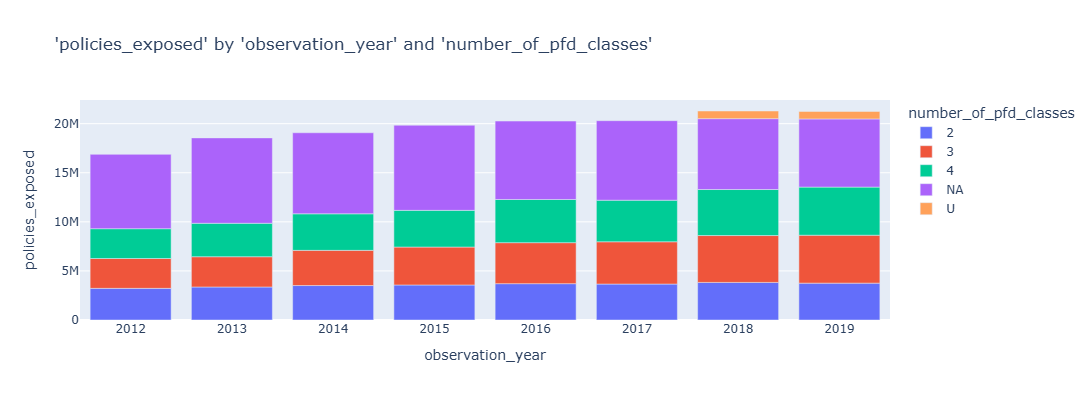

In [107]:
charters.chart(
    df=model_data,
    x_axis="observation_year",
    y_axis="policies_exposed",
    color="number_of_pfd_classes",
    type="bar",
)

In [108]:
# charters.scatter(df=df, target="qx_raw", numeric=True, sample_nbr=1000).show()

## PDP

### Load Model

In [109]:
# load
model_build = False
model_load = True
model_save = False

In [110]:
model_name = "cat_1219_amt"

In [111]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=False,
    preset="pass",
)

 2026-07-06 00:36:47 | morai.forecast.preprocessors | INFO     | using 'pass' preset which makes all features passthrough 
 2026-07-06 00:36:47 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-07-06 00:36:47 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-07-06 00:36:51 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['duration', 'attained_age', 'observation_year', 'sex', 'smoker_status', 'class_enh', 'insurance_plan', 'binned_face'] 


In [112]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

In [113]:
cat_features = feature_dict["ordinal"] + feature_dict["ohe"] + feature_dict["nominal"]
cat_features = list(set(cat_features) & set(model_features))

In [114]:
from catboost import CatBoostRegressor

if model_build:
    model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        cat_features=cat_features,
        one_hot_max_size=11,
        loss_function='Poisson',
        eval_metric='Poisson',
    )
    model.fit(X, y, sample_weight=weights, verbose=0)
if model_load:
    model = joblib.load(helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"loaded model '{model_name}'. type: {type(model)}")
if model_save:
    joblib.dump(model, helpers.FILES_PATH / "models" / f"{model_name}.joblib")
    logger.info(f"saved model '{model_name}'. type: {type(model)}")

model_params = {"weights": True}
model_params.update(model.get_params())

 2026-07-06 00:38:41 | __main__ | INFO     | loaded model 'cat_1219_amt'. type: <class 'catboost.core.CatBoostRegressor'> 


### Cat - Oberservation Year

This shows that the perm product is not too high when accounting for the other variables

 2026-07-06 00:39:01 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-07-06 00:39:01 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-06 00:39:01 | morai.experience.charters | INFO     | x_axis: [observation_year] type: [passthrough] center: [global] 
 2026-07-06 00:39:09 | morai.experience.charters | INFO     | Creating 8 predictions. 


Processing:   0%|          | 0/8 [00:00<?, ?combo/s]

 2026-07-06 00:39:59 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


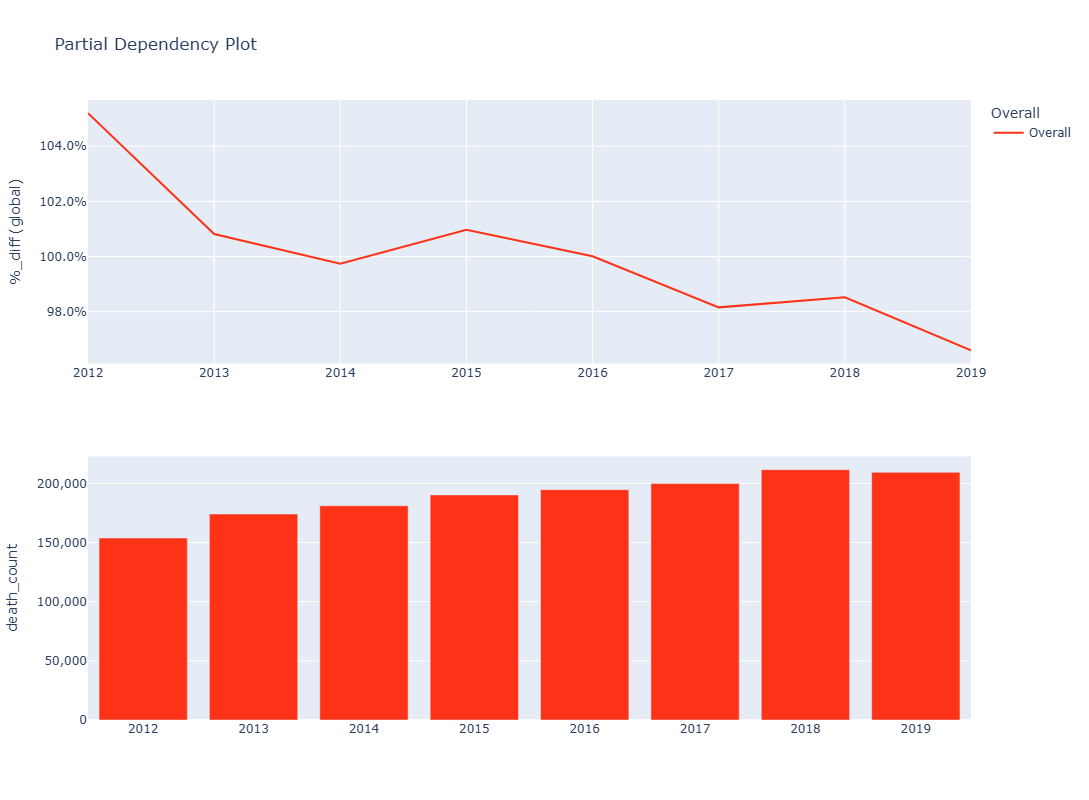

In [115]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="observation_year",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

### Cat - AA/Underwriting

This shows that for a 2 class system there seems to be wear-off of underwriting, but does persist in later ages

 2026-07-06 00:45:11 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-07-06 00:45:11 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-06 00:45:11 | morai.experience.charters | INFO     | x_axis: [attained_age] type: [passthrough] center: [per_x] 
 2026-07-06 00:45:11 | morai.experience.charters | INFO     | Line feature: [class_enh] type: [passthrough] 
 2026-07-06 00:45:11 | morai.experience.charters | INFO     | Creating 62 predictions. 
 2026-07-06 00:45:11 | morai.experience.charters | INFO     | Running '11' cores for parallel processing. 


Processing:   0%|          | 0/62 [00:00<?, ?combo/s]

 2026-07-06 00:45:15 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


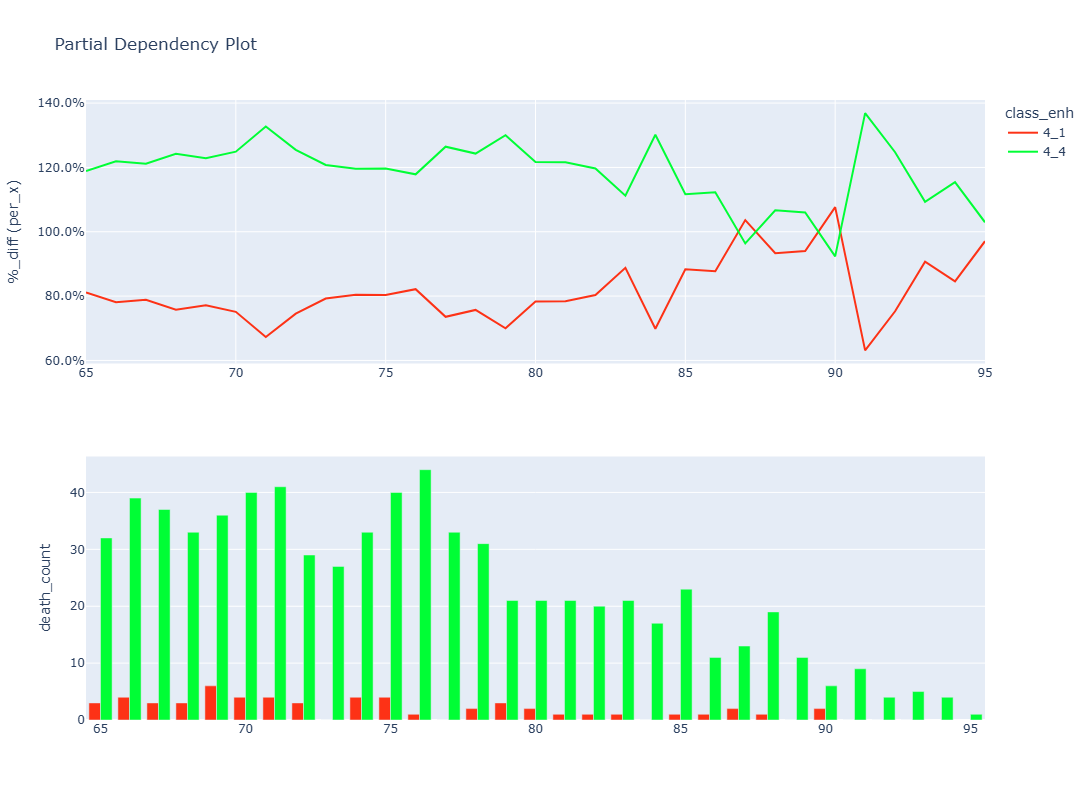

In [116]:
charters.pdp(
    model=model,
    df=md_encoded[
        (
            md_encoded["class_enh"].isin(["4_1", "4_4"])
            & (md_encoded["insurance_plan"] == "UL")
            & (md_encoded["attained_age"] >= 65)
            & (md_encoded["attained_age"] <= 95)
        )
    ],
    x_axis="attained_age",
    line_color="class_enh",
    weight="amount_exposed",
    mapping=mapping,
    center="per_x",
    secondary="death_count",
    display=True,
    n_jobs=-1,
)

### Cat - AA/Smoker

There is a similar observation with smoker

 2026-07-06 00:45:16 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-07-06 00:45:16 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-06 00:45:16 | morai.experience.charters | INFO     | x_axis: [attained_age] type: [passthrough] center: [per_x] 
 2026-07-06 00:45:16 | morai.experience.charters | INFO     | Line feature: [smoker_status] type: [passthrough] 
 2026-07-06 00:45:16 | morai.experience.charters | INFO     | Creating 62 predictions. 
 2026-07-06 00:45:16 | morai.experience.charters | INFO     | Running '11' cores for parallel processing. 


Processing:   0%|          | 0/62 [00:00<?, ?combo/s]

 2026-07-06 00:45:55 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


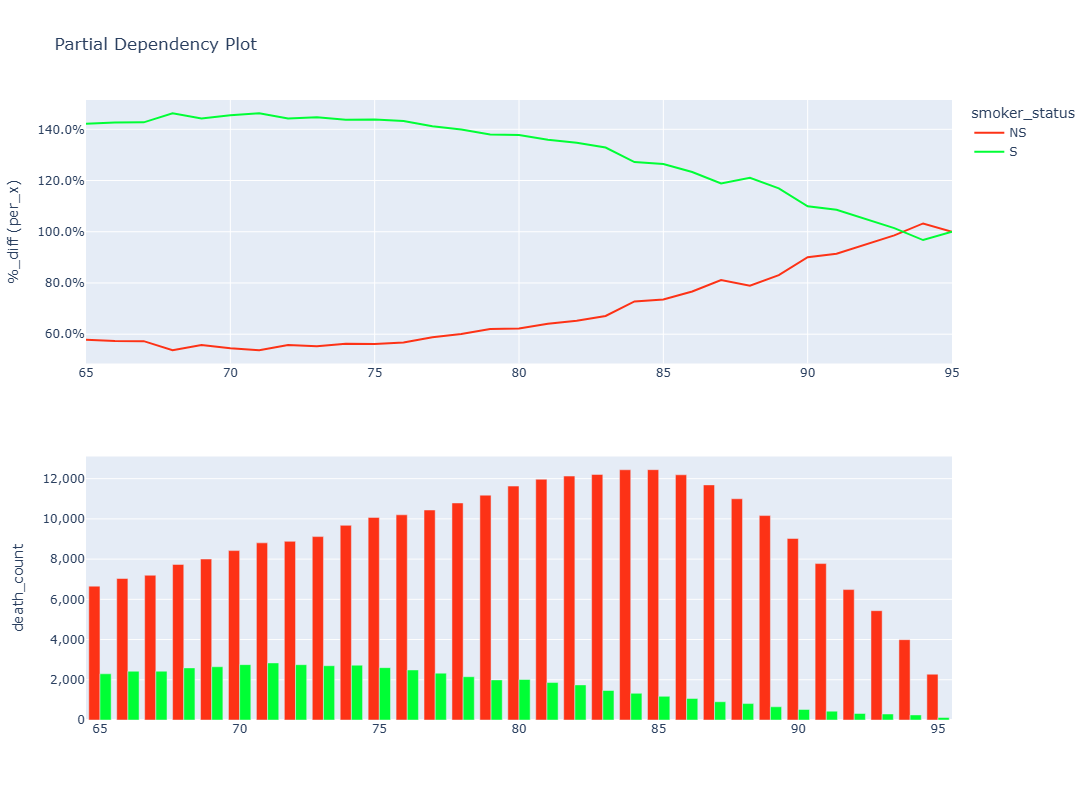

In [117]:
charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["insurance_plan"] == "UL")
            & (md_encoded["attained_age"] >= 65)
            & (md_encoded["attained_age"] <= 95)
        )
    ],
    x_axis="attained_age",
    line_color="smoker_status",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    center="per_x",
    display=True,
    n_jobs=-1,
)

### Cat - duration

 2026-07-06 00:46:50 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-07-06 00:46:50 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-06 00:46:50 | morai.experience.charters | INFO     | x_axis: [duration] type: [passthrough] center: [global] 
 2026-07-06 00:46:50 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [passthrough] 
 2026-07-06 00:46:51 | morai.experience.charters | INFO     | Creating 180 predictions. 


Processing:   0%|          | 0/180 [00:00<?, ?combo/s]

 2026-07-06 00:54:07 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


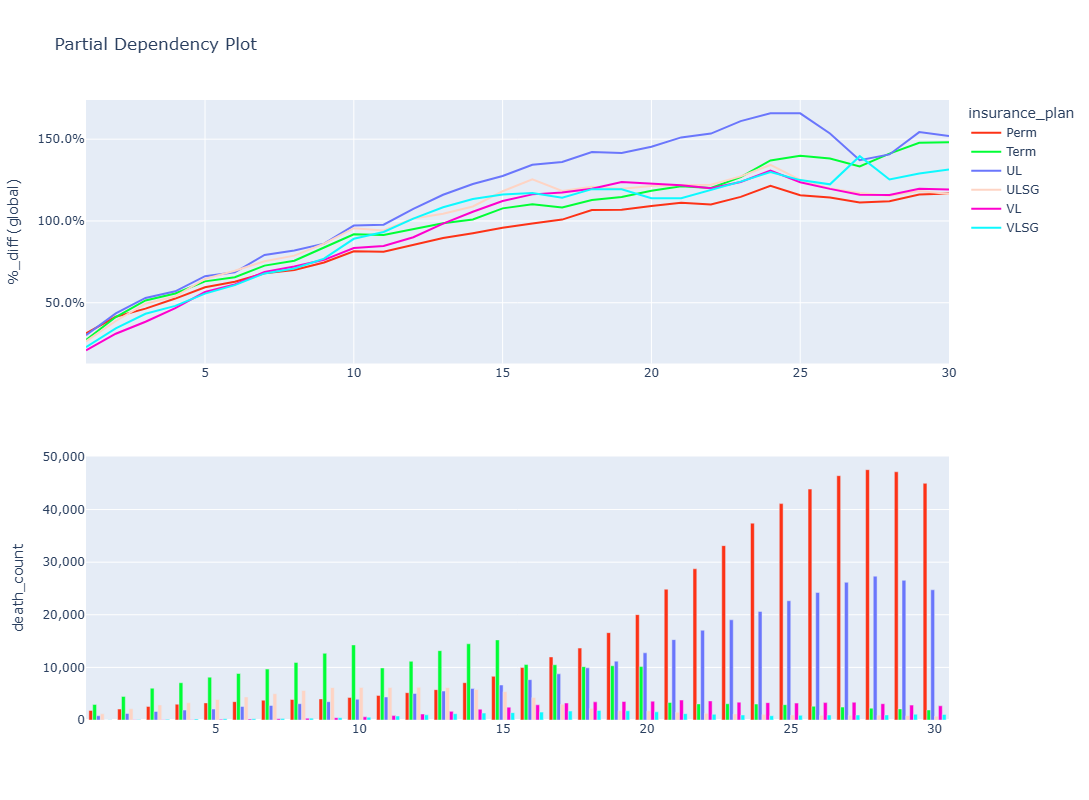

In [118]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="duration",
    line_color="insurance_plan",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

### Cat - Year/Insurance

This shows that UL, ULSG, VLSG had upticks in 2018-2019, while Perm had a noticeable decrease. This may be related to company differences in 2018-2019

 2026-07-06 00:54:36 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-07-06 00:54:36 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-06 00:54:36 | morai.experience.charters | INFO     | x_axis: [observation_year] type: [passthrough] center: [global] 
 2026-07-06 00:54:36 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [passthrough] 
 2026-07-06 00:54:44 | morai.experience.charters | INFO     | Creating 48 predictions. 
 2026-07-06 00:54:44 | morai.experience.charters | INFO     | Running '11' cores for parallel processing. 


Processing:   0%|          | 0/48 [00:00<?, ?combo/s]

 2026-07-06 00:58:10 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


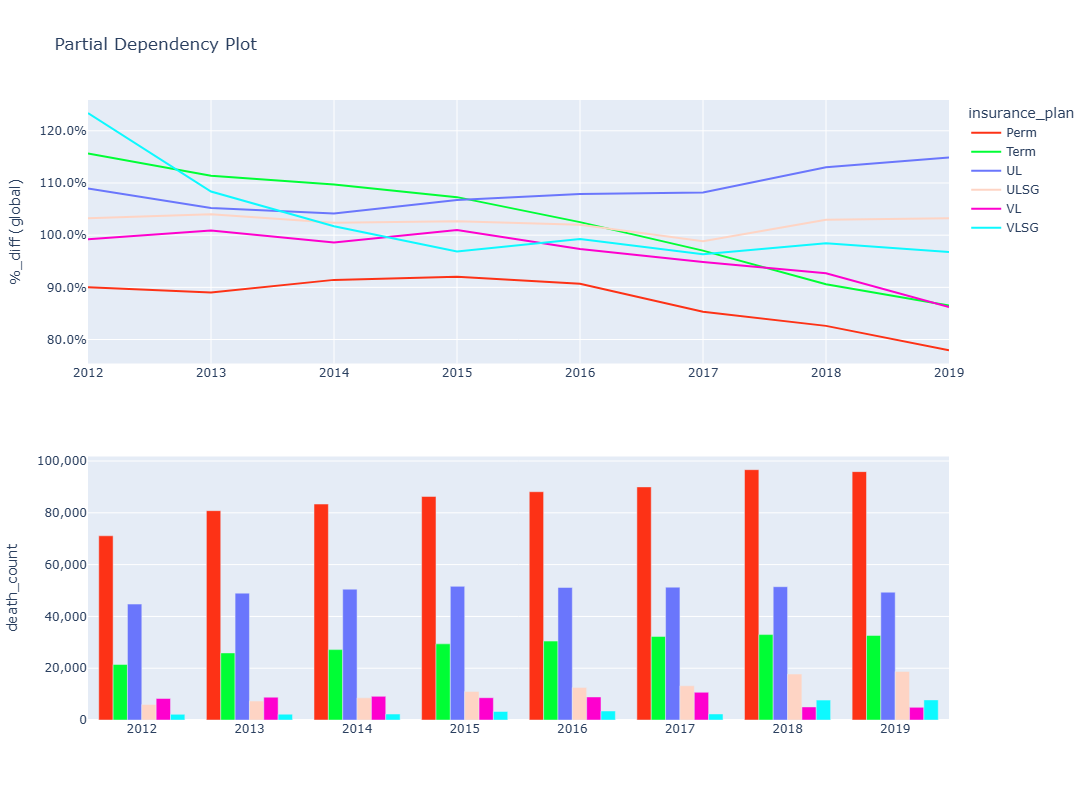

In [119]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="observation_year",
    line_color="insurance_plan",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
    n_jobs=-1,
)

### Cat - MI

The following compares PDP vs. ALE mortality improvement

PDP
- the PDP shows an overall improvement of 0.9% per year
- When splitting by attained age, it is seen that the annual improvement is relatively consistent of 1.4% for each age group. The annual improvement is calculated using a regression.

ALE
- The ALE is able to capture improvement better as it compares similar cells together, which helps when features are correlated. A PDP will averages to cells that are not likely to occur (e.g. 90 year-old that was newly issued), while an ALE will only compare cells that actually occur. When duration and attained age are correlated it is helpful
- ALE sees a decreasing improvement by attained age

In [35]:
def banded_mi_trend(
    df,
    x="observation_year",
    band="age_band",
    value="%_diff",
    weight="death_count",
):
    """Estimate annual mortality improvement by band via weighted log-linear regression.

    Fits log(value) ~ x within each band, weighted by sqrt(weight)

    Parameters
    ----------
    df : pd.DataFrame
        Data with one row per band and x value (e.g. PDP output).
    x : str
        Column with the time variable (e.g. observation year).
    band : str
        Column to group by (e.g. age band).
    value : str
        Column with the mortality measure to trend. Must be positive.
    weight : str
        Column with regression weights (e.g. death counts).

    Returns
    -------
    pd.DataFrame
        One row per band with columns [band, 'annual_pct_diff', 'r2'].
    """
    results = []
    for band_name, group in df.groupby(band, observed=True):
        group = group.sort_values(x)
        years = group[x].to_numpy(float)
        log_values = np.log(group[value].to_numpy())
        weights = np.sqrt(group[weight].to_numpy(float))

        slope, intercept = np.polyfit(years, log_values, 1, w=weights)
        fitted = slope * years + intercept

        results.append(
            {
                band: band_name,
                "annual_pct_diff": np.exp(-slope) - 1,
                "r2": _weighted_r2(log_values, fitted, weights),
            }
        )
    return pd.DataFrame(results)

def _weighted_r2(y, y_pred, weights):
    """Weighted coefficient of determination.

    Parameters
    ----------
    y : np.ndarray
        Observed values.
    y_pred : np.ndarray
        Fitted values.
    weights : np.ndarray
        Regression weights (proportional to 1/sigma).

    Returns
    -------
    float
        Weighted r-squared.
    """
    w_norm = weights**2 / (weights**2).sum()
    y_mean = (w_norm * y).sum()
    ss_res = (w_norm * (y - y_pred) ** 2).sum()
    ss_tot = (w_norm * (y - y_mean) ** 2).sum()
    return 1 - ss_res / ss_tot

In [44]:
pdp_df = charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["attained_age"] >= 50)
            & (md_encoded["attained_age"] <= 95)
            & (md_encoded["observation_year"].between(2012, 2019))
        )
    ],
    x_axis="observation_year",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=False,
    n_jobs=-1,
)

trend = banded_mi_trend(
    pdp_df,
    x="observation_year",
    band="Overall",
    value="%_diff",
    weight="death_count",
)
trend

 2026-07-12 22:23:10 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-07-12 22:23:10 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-07-12 22:23:10 | morai.experience.charters | INFO     | x_axis: [observation_year] type: [passthrough] center: [global] 
 2026-07-12 22:23:16 | morai.experience.charters | INFO     | Creating 8 predictions. 
 2026-07-12 22:23:16 | morai.experience.charters | INFO     | Running '16' cores for parallel processing. 


Processing:   0%|          | 0/8 [00:00<?, ?combo/s]

 2026-07-12 22:26:02 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


,Overall,annual_pct_diff,r2
0,Overall,0.00896,0.78581


In [ ]:
pdp_df = charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["attained_age"] >= 50)
            & (md_encoded["attained_age"] <= 95)
        )
    ],
    x_axis="observation_year",                
    line_color="attained_age",                   
    weight="policies_exposed",
    secondary="death_count",
    mapping=mapping,
    center="global",                             
    display=False,
    n_jobs=-1,
)

In [123]:
pdp_df["age_band"] = pd.cut(pdp_df["attained_age"], bins=[50, 60, 70, 80, 87, 95],
                            right=True, include_lowest=True)
banded = (
    pdp_df.assign(_w=pdp_df["%_diff"] * pdp_df["death_count"])
          .groupby(["age_band", "observation_year"], observed=True)
          .agg(_w=("_w", "sum"), death_count=("death_count", "sum"))
          .reset_index()
)
banded["%_diff"] = banded["_w"] / banded["death_count"]

banded_mi_trend(banded, x="observation_year", band="age_band",
                value="%_diff", weight="death_count")

,age_band,annual_pct_diff,r2
0,"(49.999, 60.0]",0.01300,0.90093
1,"(60.0, 70.0]",0.01095,0.95843
2,"(70.0, 80.0]",0.01539,0.94246
3,"(80.0, 87.0]",0.01497,0.43308
4,"(87.0, 95.0]",0.01506,0.28192


using ALE to look at local effects, which will look at predictions that are changing within the age bands

In [40]:
# add age_band
md_encoded["age_band"] = pd.cut(
    md_encoded["attained_age"],
    bins=[50, 60, 70, 80, 87, 95],
    right=True, include_lowest=True,
)

# creating ale df
ale_df = charters.ale(
    model=model,
    df=md_encoded[
        (
            (md_encoded["attained_age"] >= 50)
            & (md_encoded["attained_age"] <= 95)
            & (md_encoded["observation_year"].between(2012, 2019))
        )
    ],
    x_axis="observation_year",            
    line_color="age_band",                 
    weight="policies_exposed",
    secondary="death_count",
    mapping=mapping,
    center="global",
    multiplicative=True,                             
    display=False,
    n_jobs=-1,
)

 2026-07-12 22:02:08 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for ALE plot. 
 2026-07-12 22:02:08 | morai.experience.charters | INFO     | Weights: [policies_exposed] 
 2026-07-12 22:02:09 | morai.experience.charters | INFO     | x_axis: [observation_year] discrete: [True with 7 bins] multiplicative: [True] center: [global] 
 2026-07-12 22:02:09 | morai.experience.charters | INFO     | Line feature: [age_band] 
 2026-07-12 22:02:14 | morai.experience.charters | INFO     | Creating 35 local-effect predictions. 
 2026-07-12 22:02:18 | morai.experience.charters | INFO     | Running '16' cores for parallel processing. 


Processing:   0%|          | 0/35 [00:00<?, ?combo/s]

In [41]:
banded_mi_trend(ale_df, x="observation_year", band="age_band",
                value="%_diff", weight="death_count")

,age_band,annual_pct_diff,r2
0,"(49.999, 60.0]",0.01755,0.92522
1,"(60.0, 70.0]",0.01466,0.98486
2,"(70.0, 80.0]",0.00658,0.72692
3,"(80.0, 87.0]",-0.00292,0.15122
4,"(87.0, 95.0]",-0.01204,0.64070


## Shap

In [125]:
import shap

explainer = shap.TreeExplainer(model)

In [126]:
X_sample = X_train.sample(5000, random_state=42)
shap_values = explainer(X_sample)

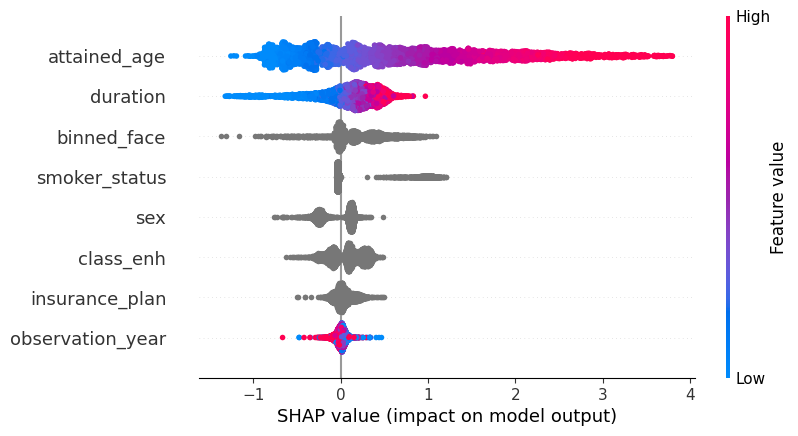

In [127]:
shap.plots.beeswarm(shap_values)

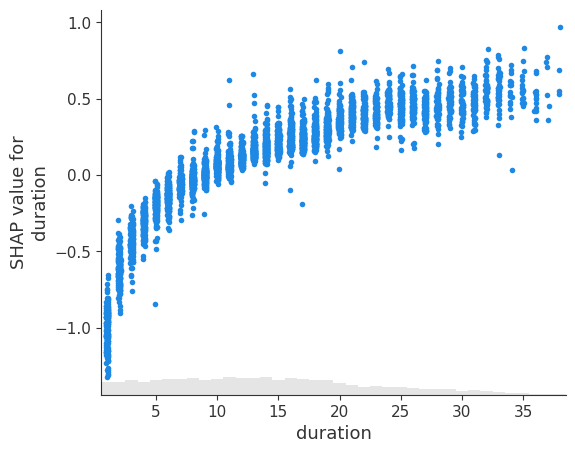

In [128]:
shap.plots.scatter(shap_values[:, "duration"])

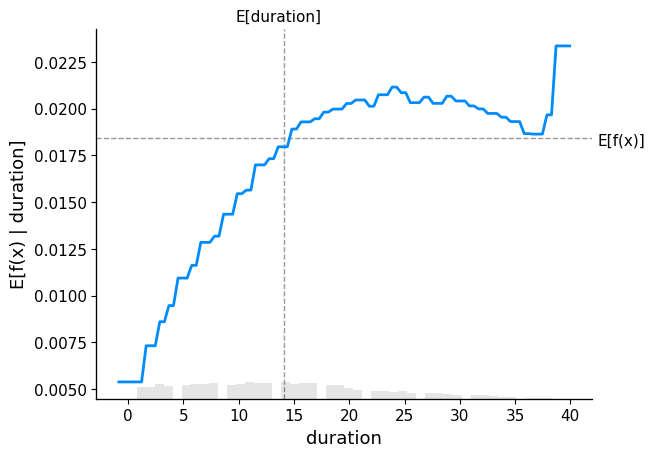

In [129]:
shap.partial_dependence_plot(
    "duration",
    model.predict,
    X_sample,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

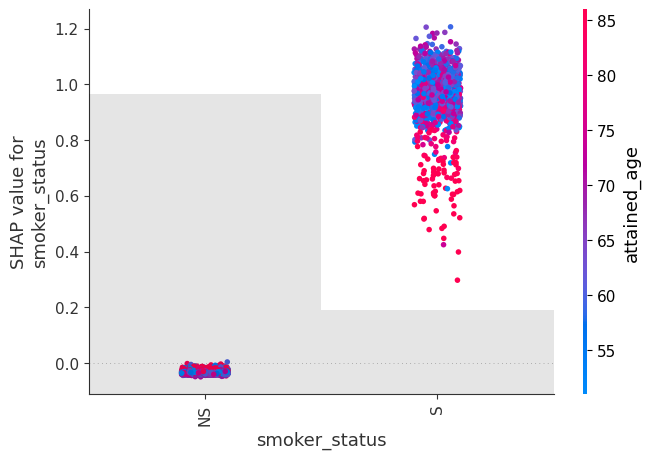

In [132]:
shap.plots.scatter(
    shap_values[:, "smoker_status"],
    color=shap_values,
)

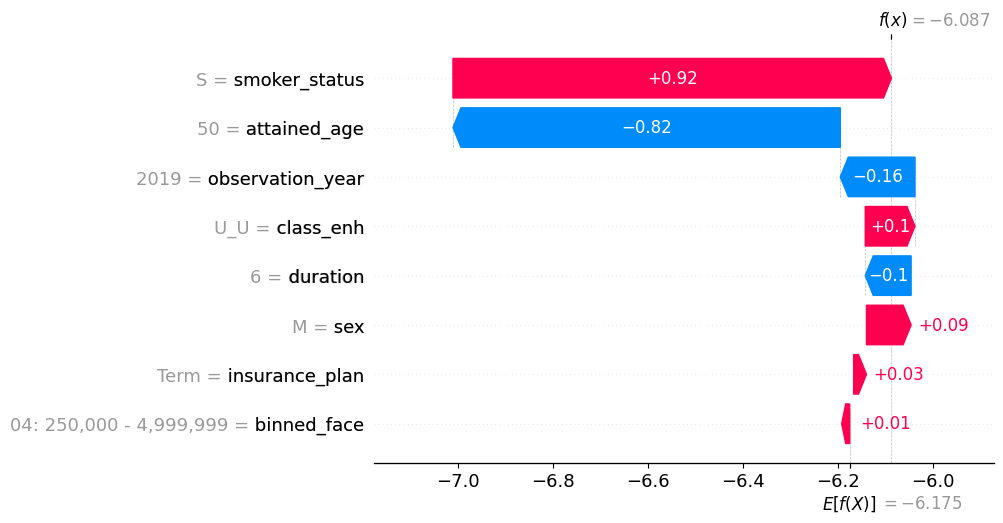

In [131]:
shap.plots.waterfall(shap_values[0])

# Reload

In [133]:
importlib.reload(charters)

<module 'morai.experience.charters' from '/usr/local/lib/python3.12/dist-packages/morai/experience/charters.py'>

In [ ]:
importlib.reload(custom_logger)

In [117]:
importlib.reload(core)

<module 'morai.models.core' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\core.py'>

In [162]:
importlib.reload(helpers)

<module 'morai.utils.helpers' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\utils\\helpers.py'>

In [163]:
importlib.reload(metrics)

<module 'morai.forecast.metrics' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\forecast\\metrics.py'>

In [164]:
importlib.reload(preprocessors)

<module 'morai.forecast.preprocessors' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\forecast\\preprocessors.py'>

# Utilities

In [245]:
jupyter_objects = helpers.memory_usage_jupyter()
jupyter_objects

,object,size_mb
0,model_data,394.32
1,md_encoded,388.04
2,X,49.16
3,X_train,46.02
4,weights_train,13.39
...,...,...
60,model_name,0.00
61,initial_row_count,0.00
62,model_save,0.00
63,model_load,0.00


In [ ]:
helpers.delete_jupyter_objects(objects=list(jupyter_objects["object"]))

# Unused

In [39]:
fig = charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["attained_age"] >= 50)
            & (md_encoded["attained_age"] <= 95)
            & (
                (md_encoded["observation_year"] == 2012)
                | (md_encoded["observation_year"] == 2019)
            )
        )
    ],
    x_axis="attained_age",
    line_color="observation_year",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    center="raw",
    x_bins=5,
    display=False,
    n_jobs=-1,
)
pd.options.display.float_format = "{:,.5f}".format
pivot = fig.pivot(index='attained_age', columns='observation_year', values='%_diff')
pivot['annual_pct_diff'] = (pivot[2012] / pivot[2019]) ** (1/7) - 1
pivot

 2026-06-24 02:59:58 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-06-24 02:59:58 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-06-24 02:59:58 | morai.experience.charters | INFO     | x_axis: [attained_age] type: [passthrough] center: [raw] 
 2026-06-24 02:59:58 | morai.experience.charters | INFO     | Line feature: [observation_year] type: [passthrough] 
 2026-06-24 02:59:58 | morai.experience.charters | INFO     | Creating 92 predictions. 
 2026-06-24 02:59:58 | morai.experience.charters | INFO     | Running '6' cores for parallel processing. 


Processing:   0%|          | 0/92 [00:00<?, ?combo/s]

 2026-06-24 03:03:27 | morai.experience.charters | INFO     | Binning feature: [attained_age] with 5 bins 
 2026-06-24 03:03:27 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


observation_year,2012,2019,annual_pct_diff
attained_age,,,
50~58,0.00155,0.00138,0.01617
59~67,0.00332,0.00304,0.01304
68~76,0.00852,0.00733,0.02172
77~85,0.02639,0.02237,0.02390
86~95,0.06826,0.06169,0.01456


In [38]:
fig = charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["attained_age"] >= 50)
            & (md_encoded["attained_age"] <= 95)
        )
    ],
    x_axis="observation_year",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=False,
    n_jobs=-1,
)
fig

 2026-06-24 02:58:46 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-06-24 02:58:46 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-06-24 02:58:46 | morai.experience.charters | INFO     | x_axis: [observation_year] type: [passthrough] center: [global] 
 2026-06-24 02:58:47 | morai.experience.charters | INFO     | Creating 8 predictions. 
 2026-06-24 02:58:47 | morai.experience.charters | INFO     | Running '6' cores for parallel processing. 


Processing:   0%|          | 0/8 [00:00<?, ?combo/s]

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


 2026-06-24 02:59:57 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


,observation_year,Overall,pred,%_diff,death_count
7,2012,Overall,0.00508,1.05168,149572
1,2013,Overall,0.00484,1.00282,168799
6,2014,Overall,0.00478,0.99063,175545
5,2015,Overall,0.00487,1.00725,183398
2,2016,Overall,0.00482,0.99885,187904
0,2017,Overall,0.00476,0.98528,191947
4,2018,Overall,0.00479,0.99109,203702
3,2019,Overall,0.00470,0.97241,201643


In [50]:
import numpy as np, pandas as pd

def age_standardized_ae_trend(
    df, *, age="attained_age", year="observation_year",
    rate="qx_raw", exposure="amount_exposed",
    bins=(50,60,70,80,95), strata=None, standard="pooled",
):
    """Direct age- (and optional duration-) standardized raw A/E improvement
    per age band. Holds the within-band mix FIXED across calendar years so a
    drifting mix can't masquerade as a mortality trend.

    standard : 'pooled' (all-years mix) or a specific year (e.g. 2012).
    strata   : columns to standardize on within a band; default [age].
    Returns one row per band: crude vs standardized annual improvement.
    """
    strata = strata or [age]
    d = df[[age, year, rate, exposure, *[s for s in strata if s not in (age,)]]].copy()
    d["_claims"] = d[rate] * d[exposure]                 # amount of claims per cell
    d["band"] = pd.cut(d[age], bins=bins, include_lowest=True)

    keys = ["band", year, *strata]
    cells = (d.groupby(keys, observed=True)
               .agg(claims=("_claims","sum"), expo=(exposure,"sum")).reset_index())
    cells["rate"] = cells["claims"] / cells["expo"]

    # fixed standard weights within band, over the strata
    src = cells if standard == "pooled" else cells[cells[year] == standard]
    std = (src.groupby(["band", *strata], observed=True)["expo"].sum()
              .rename("w").reset_index())

    m = cells.merge(std, on=["band", *strata], how="left")
    m["_num"] = m["rate"] * m["w"]
    std_rate = (m.groupby(["band", year], observed=True)
                  .agg(_num=("_num","sum"), _den=("w","sum"),
                       claims=("claims","sum"), expo=("expo","sum")).reset_index())
    std_rate["std_rate"]   = std_rate["_num"] / std_rate["_den"]
    std_rate["crude_rate"] = std_rate["claims"] / std_rate["expo"]

    def mi(g, col):
        yr = g[year].to_numpy(float); ly = np.log(g[col].to_numpy())
        w  = np.sqrt(g["expo"].to_numpy(float))          # precision weight
        slope = np.polyfit(yr, ly, 1, w=w)[0]
        return np.exp(-slope) - 1                         # +ve = improvement

    rows = []
    for b, g in std_rate.groupby("band", observed=True):
        g = g.sort_values(year)
        rows.append({"band": b,
                     "crude_mi": mi(g, "crude_rate"),
                     "age_std_mi": mi(g, "std_rate")})
    return pd.DataFrame(rows)

In [52]:
res = age_standardized_ae_trend(
    md_encoded,
    age="attained_age", year="observation_year",
    rate="qx_raw", exposure="amount_exposed",
    bins=(50, 60, 70, 80, 95),
    strata=["attained_age", "duration"],   # standardize on what ALE conditions on
)
res

,band,crude_mi,age_std_mi
0,"(49.999, 60.0]",0.01225,0.02656
1,"(60.0, 70.0]",0.01655,0.02960
2,"(70.0, 80.0]",0.00482,0.01601
3,"(80.0, 95.0]",-0.04665,0.00625


In [53]:
import numpy as np, pandas as pd

def ae_by_band_year(
    df, model, *, model_features,
    age="attained_age", year="observation_year",
    rate="qx_raw", exposure="amount_exposed", bins=(50,60,70,80,87,95),
):
    """Actual-vs-Expected by band x year, and the A/E drift per year.

    A = sum(qx_raw * expo)   (actual claims)
    E = sum(model_pred * expo) (expected claims)
    ae_drift_per_yr ~ 0  -> model captures that band's calendar trend (ALE trustworthy)
    ae_drift < 0         -> A/E falling: model UNDER-states improvement (ALE too negative)
    ae_drift > 0         -> A/E rising:  model OVER-states improvement (ALE too positive)
    """
    d = df.copy()
    d["band"] = pd.cut(d[age], bins=bins, include_lowest=True)
    d["_A"] = d[rate] * d[exposure]
    d["_E"] = np.asarray(model.predict(d[model_features]), float) * d[exposure]
    g = (d.groupby(["band", year], observed=True)
           .agg(A=("_A","sum"), E=("_E","sum")).reset_index())
    g["AE"] = g["A"] / g["E"]
    rows=[]
    for b, gg in g.groupby("band", observed=True):
        gg = gg.sort_values(year)
        yr = gg[year].to_numpy(float); lae = np.log(gg["AE"].to_numpy())
        w  = np.sqrt(gg["E"].to_numpy(float))
        slope = np.polyfit(yr, lae, 1, w=w)[0]
        rows.append({"band": b, "mean_AE": gg["AE"].mean(),
                     "ae_drift_per_yr": np.exp(slope)-1})
    return g, pd.DataFrame(rows)

# ---- validate: a model that SHRINKS improvement (predicts 1%/yr, truth 2%/yr) ----
if __name__ == "__main__":
    rng=np.random.default_rng(0); rows=[]
    for y in range(2012,2020):
        for age in range(50,96):
            expo=1e8
            true=np.exp(-10+0.09*age)*0.98**(y-2012)   # truth: 2%/yr improvement
            rows.append((age,y,true,expo))
    df=pd.DataFrame(rows,columns=["attained_age","observation_year","qx_raw","amount_exposed"])
    class Shrunk:   # model under-states improvement (only 1%/yr)
        def predict(self,X): return np.exp(-10+0.09*X["attained_age"].to_numpy())*0.99**(X["observation_year"].to_numpy()-2012)
    _, drift = ae_by_band_year(df, Shrunk(), model_features=["attained_age","observation_year"],
                               bins=(50,60,70,80,95))
    pd.options.display.float_format="{:,.4%}".format
    print("Model under-states improvement (1%/yr vs true 2%/yr):")
    print(drift.to_string(index=False))
    print("\n-> ae_drift should be NEGATIVE (A/E falling) in every band, ~ -1%/yr,")
    print("   i.e. exactly the amount the model under-states the true 2% improvement.")

Model under-states improvement (1%/yr vs true 2%/yr):
          band  mean_AE  ae_drift_per_yr
(49.999, 60.0] 96.5352%         -1.0101%
  (60.0, 70.0] 96.5352%         -1.0101%
  (70.0, 80.0] 96.5352%         -1.0101%
  (80.0, 95.0] 96.5352%         -1.0101%

-> ae_drift should be NEGATIVE (A/E falling) in every band, ~ -1%/yr,
   i.e. exactly the amount the model under-states the true 2% improvement.


In [56]:
g, drift = ae_by_band_year(
    md_encoded, model,
    model_features=X.columns,
    age="attained_age", year="observation_year",
    rate="qx_raw", exposure="amount_exposed",
    bins=(50, 60, 70, 80, 87, 95),
)

In [59]:
drift

,band,mean_AE,ae_drift_per_yr
0,"(49.999, 60.0]",99.7217%,0.1539%
1,"(60.0, 70.0]",100.4054%,-0.1671%
2,"(70.0, 80.0]",99.9411%,0.0247%
3,"(80.0, 87.0]",99.9330%,0.0148%
4,"(87.0, 95.0]",100.0791%,-0.0197%
